# Laboratorio 1. Series de Tiempo

## Análisis preliminar de las series de tiempo

Fernando Rueda - 23748

Fernando Hernández - 23645

Este cuaderno cubre los puntos 2 y 3 del laboratorio y el análisis preliminar del punto 4
(incisos a al f) para cinco de las siete series construidas: el total de visitantes (serie
obligatoria), la región América Del Centro y las tres fronteras, La Aurora, Valle Nuevo y San
Cristóbal. La elección de las categorías, regiones y fronteras, viene del diagnóstico de
viabilidad de la sección 11 del análisis exploratorio.

Las series no se construyen aquí. Las produce el pipeline: `src/05_series.py` construye las
siete series mensuales y `src/06_split.py` hace la partición temporal 70/30. Este cuaderno las
lee ya particionadas y trabaja solo sobre el conjunto de entrenamiento, como pide el enunciado.
El conjunto de prueba queda reservado para evaluar los pronósticos.

Antes de correr este cuaderno hay que ejecutar el pipeline desde la raíz del proyecto con
`python src/run_pipeline.py`. En cada sección mostramos primero la evidencia y después nuestra
lectura de ella.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")  # statsmodels avisa cuando KPSS satura su tabla de p-valores

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(RAIZ / "src"))
FIGURAS = RAIZ / "reports" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

# Paleta categórica validada para daltonismo, se asigna en orden fijo y nunca se recicla.
PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
AZUL, NARANJA, AQUA, AMARILLO, MAGENTA = PALETA
GRIS = "#8a8a85"

plt.rcParams.update({
    "figure.figsize": (11, 4.2),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e4e4e0",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "font.size": 10,
    "legend.frameon": False,
})

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(FIGURAS / f"{nombre}.png", bbox_inches="tight", facecolor="white")

def miles(eje):
    eje.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

In [2]:
train = pd.read_csv(RAIZ / "data" / "processed" / "series_train.csv", parse_dates=["fecha"]).set_index("fecha").asfreq("MS")
test = pd.read_csv(RAIZ / "data" / "processed" / "series_test.csv", parse_dates=["fecha"]).set_index("fecha").asfreq("MS")

print(f"Entrenamiento: {len(train)} meses ({len(train) / (len(train) + len(test)):.0%}), "
      f"{train.index.min():%Y-%m} a {train.index.max():%Y-%m}")
print(f"Prueba       : {len(test)} meses ({len(test) / (len(train) + len(test)):.0%}), "
      f"{test.index.min():%Y-%m} a {test.index.max():%Y-%m}")
print(f"Series       : {list(train.columns)}")

Entrenamiento: 147 meses (70%), 2009-01 a 2021-03
Prueba       : 63 meses (30%), 2021-04 a 2026-06
Series       : ['total', 'region: América Del Centro', 'region: América Del Norte', 'region: Europa', 'frontera: La Aurora', 'frontera: Valle Nuevo', 'frontera: San Cristóbal']


## 1. La partición y las siete series

La partición es temporal, no aleatoria. El 70% inicial (147 meses, de enero 2009 a marzo 2021)
es el entrenamiento y el 30% final (63 meses, de abril 2021 a junio 2026) es la prueba. En
series de tiempo la prueba debe ser posterior al entrenamiento, porque el objetivo es
pronosticar hacia el futuro y una partición aleatoria filtraría información del futuro al
modelo.

Primero el inventario que pide el inciso 4a para las siete series, y un vistazo conjunto para
ubicar dónde cae el corte.

In [3]:
inventario = pd.DataFrame({
    "inicio": [f"{train.index.min():%Y-%m}"] * len(train.columns),
    "fin entrenamiento": [f"{train.index.max():%Y-%m}"] * len(train.columns),
    "fin serie completa": [f"{test.index.max():%Y-%m}"] * len(train.columns),
    "frecuencia": ["mensual (12 obs/año)"] * len(train.columns),
    "meses train": [train[c].notna().sum() for c in train.columns],
    "acumulado train": [round(train[c].sum()) for c in train.columns],
}, index=train.columns)
inventario

,inicio,fin entrenamiento,fin serie completa,frecuencia,meses train,acumulado train
total,2009-01,2021-03,2026-06,mensual (12 obs/año),147,31490031
region: América Del Centro,2009-01,2021-03,2026-06,mensual (12 obs/año),147,23135833
region: América Del Norte,2009-01,2021-03,2026-06,mensual (12 obs/año),147,5633945
region: Europa,2009-01,2021-03,2026-06,mensual (12 obs/año),147,1410125
frontera: La Aurora,2009-01,2021-03,2026-06,mensual (12 obs/año),147,13062483
frontera: Valle Nuevo,2009-01,2021-03,2026-06,mensual (12 obs/año),147,7149038
frontera: San Cristóbal,2009-01,2021-03,2026-06,mensual (12 obs/año),147,2732163


findfont: Failed to find font weight semibold, now using 700.


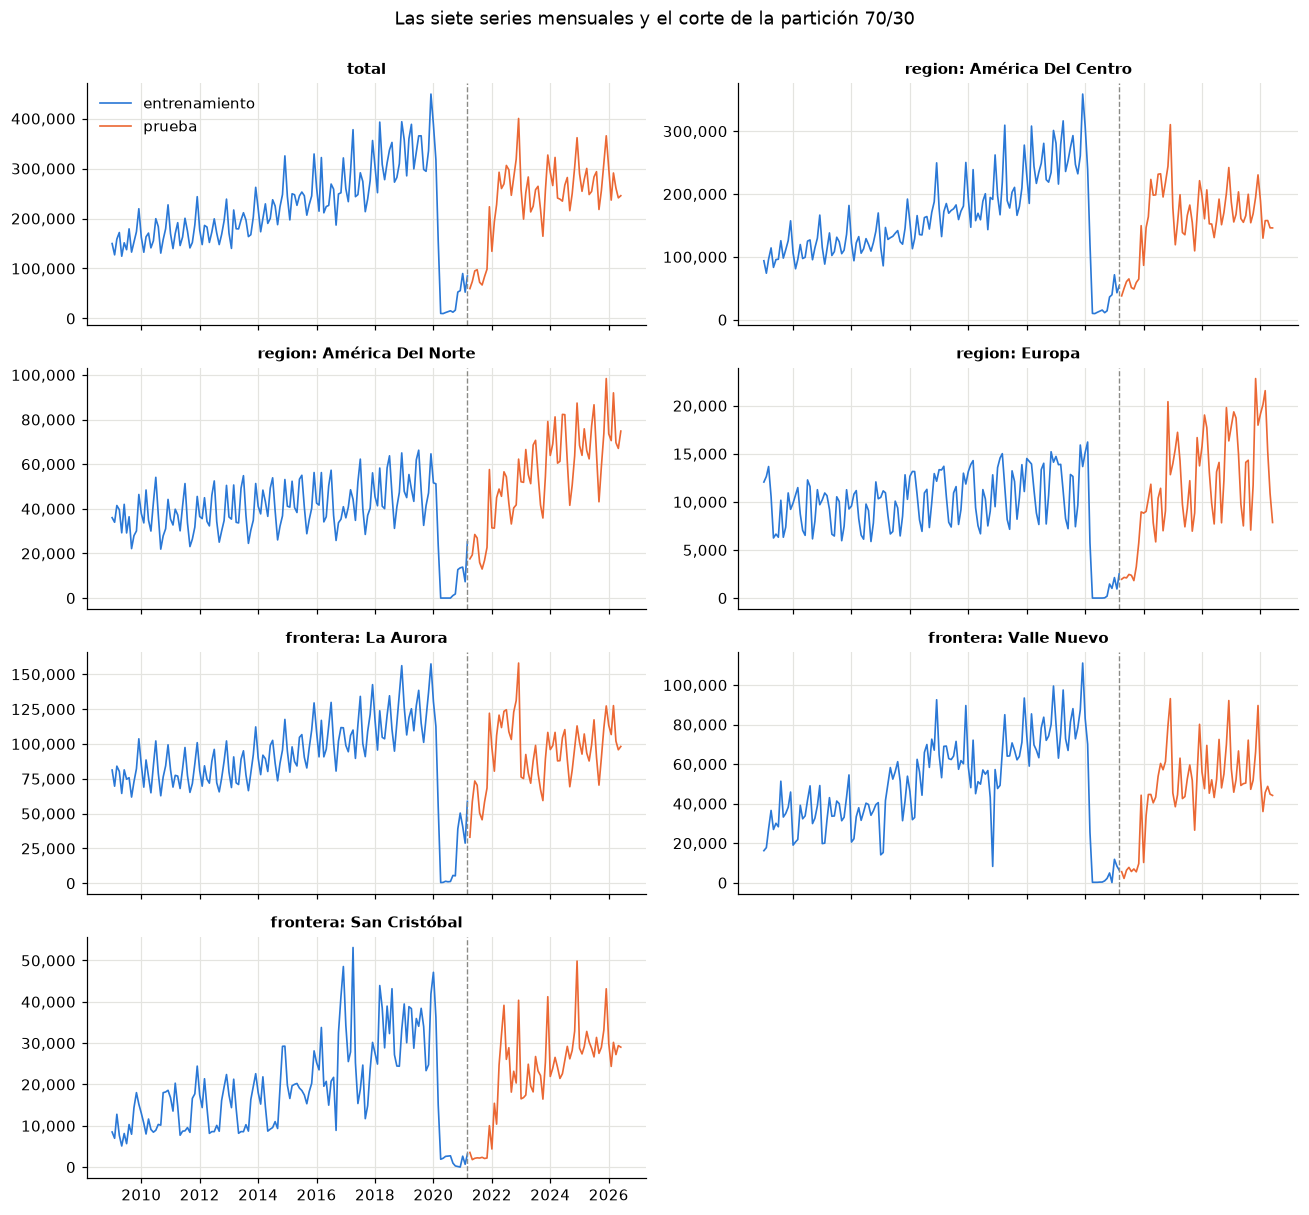

In [4]:
fig, ejes = plt.subplots(4, 2, figsize=(12, 11), sharex=True)
ejes = ejes.ravel()
for eje, columna in zip(ejes, train.columns):
    eje.plot(train.index, train[columna], color=AZUL, lw=1.1, label="entrenamiento")
    eje.plot(test.index, test[columna], color=NARANJA, lw=1.1, label="prueba")
    eje.axvline(train.index.max(), color=GRIS, ls="--", lw=0.9)
    eje.set_title(columna, fontsize=10)
    miles(eje)
ejes[0].legend(loc="upper left")
ejes[-1].axis("off")
fig.suptitle("Las siete series mensuales y el corte de la partición 70/30", y=1.0)
guardar("series-panorama-particion")
plt.show()

Las siete series comparten inicio (enero 2009), frecuencia mensual y el mismo corte de
partición, así que todos los modelos se evaluarán sobre el mismo horizonte de 63 meses.

El corte cae en marzo de 2021. Eso deja el colapso de la pandemia al final del entrenamiento y
toda la recuperación en la prueba: el modelo se entrena con una serie cuyo último año es anómalo
y se evalúa sobre un régimen que nunca vio. No es una decisión nuestra, es consecuencia de la
proporción que fija el enunciado, pero hay que tenerla presente al leer las métricas de error.
Va a castigar más a los modelos que extrapolen el nivel deprimido del final del entrenamiento.

Las siete series tienen la misma anatomía, crecimiento hasta 2019 y colapso en 2020, con
amplitudes distintas. En este cuaderno analizamos las siete: el total (obligatoria), las tres regiones de mayor
peso (América Del Centro, América Del Norte y Europa) y las tres fronteras principales (La
Aurora, Valle Nuevo y San Cristóbal).

Para no repetir el mismo bloque de código en cada serie, definimos aquí las funciones que usa cada
serie: gráfico con estadísticos móviles, descomposición, pruebas de estacionariedad y
correlogramas.

In [5]:
def graficar_serie(serie, titulo, nombre_figura):
    fig, eje = plt.subplots(figsize=(12, 4.4))
    eje.plot(serie, color=AZUL, lw=1.2)
    eje.axvspan(pd.Timestamp("2020-03-01"), serie.index.max(), color=NARANJA, alpha=0.12)
    eje.set_title(titulo)
    miles(eje)
    guardar(nombre_figura)
    plt.show()


def graficar_moviles(serie, titulo, nombre_figura, ventana=12):
    fig, ejes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
    ejes[0].plot(serie, color=GRIS, lw=0.9, label="serie")
    ejes[0].plot(serie.rolling(ventana).mean(), color=AZUL, lw=1.6, label=f"media móvil {ventana}m")
    ejes[0].legend(loc="upper left")
    ejes[0].set_title(titulo)
    miles(ejes[0])
    ejes[1].plot(serie.rolling(ventana).std(), color=NARANJA, lw=1.6, label=f"desviación móvil {ventana}m")
    ejes[1].legend(loc="upper left")
    miles(ejes[1])
    guardar(nombre_figura)
    plt.show()


def descomponer(serie, titulo, nombre_figura):
    """Descompone en ambos modelos, grafica la multiplicativa y compara los residuos.

    La comparación numérica se hace sobre el tramo prepandemia (hasta 2019-12) para
    que el colapso de 2020 no domine la varianza del residuo de ambos modelos.
    """
    desc = seasonal_decompose(serie, model="multiplicative", period=12)
    fig = desc.plot()
    fig.set_size_inches(11, 7)
    fig.suptitle(titulo, y=1.01)
    guardar(nombre_figura)
    plt.show()

    pre = serie[:"2019-12"]
    resid_add = seasonal_decompose(pre, model="additive", period=12).resid.dropna()
    resid_mul = seasonal_decompose(pre, model="multiplicative", period=12).resid.dropna()
    comparacion = pd.DataFrame({
        "residuo aditivo (rel. al nivel medio)": [resid_add.std() / pre.mean()],
        "residuo multiplicativo (rel. a 1)": [resid_mul.std()],
    }, index=["desv. estándar relativa (prepandemia)"]).round(4)
    return desc, comparacion


def tabla_estacionariedad(serie, transformaciones):
    """ADF (H0: raíz unitaria) y KPSS (H0: estacionaria) para cada transformación."""
    filas = {}
    for etiqueta, x in transformaciones.items():
        x = x.dropna()
        adf = adfuller(x, autolag="AIC")
        kp = kpss(x, regression="c", nlags="auto")
        filas[etiqueta] = {
            "ADF estadístico": round(adf[0], 3),
            "ADF p-valor": round(adf[1], 4),
            "ADF veredicto": "estacionaria" if adf[1] < 0.05 else "NO estacionaria",
            "KPSS estadístico": round(kp[0], 3),
            "KPSS p-valor": round(kp[1], 4),
            "KPSS veredicto": "estacionaria" if kp[1] >= 0.05 else "NO estacionaria",
        }
    return pd.DataFrame(filas).T


def correlogramas(x, titulo, nombre_figura, rezagos=36):
    fig, ejes = plt.subplots(1, 2, figsize=(13, 4.2))
    plot_acf(x.dropna(), lags=rezagos, ax=ejes[0], color=AZUL)
    ejes[0].set_title("ACF")
    plot_pacf(x.dropna(), lags=rezagos, ax=ejes[1], color=AZUL, method="ywm")
    ejes[1].set_title("PACF")
    fig.suptitle(titulo, y=1.02)
    guardar(nombre_figura)
    plt.show()

## 2. Serie obligatoria: total mensual de visitantes

### 2.1 Inicio, fin, frecuencia y primer vistazo

La serie de entrenamiento va de **enero 2009 a marzo 2021**, con **frecuencia mensual** (12
observaciones por año) y 147 observaciones sin huecos. La medida es visitantes, turistas más
excursionistas, la única agregación comparable en todo el rango por el cambio metodológico
de 2023 que documentamos en el análisis exploratorio.

findfont: Failed to find font weight semibold, now using 700.


Inicio     : 2009-01
Fin        : 2021-03
Frecuencia : mensual (MS), 147 observaciones
Media      : 214,218 visitantes/mes | CV = 0.41
Máximo     : 449,114 en 2019-12
Mínimo     : 9,779 en 2020-05


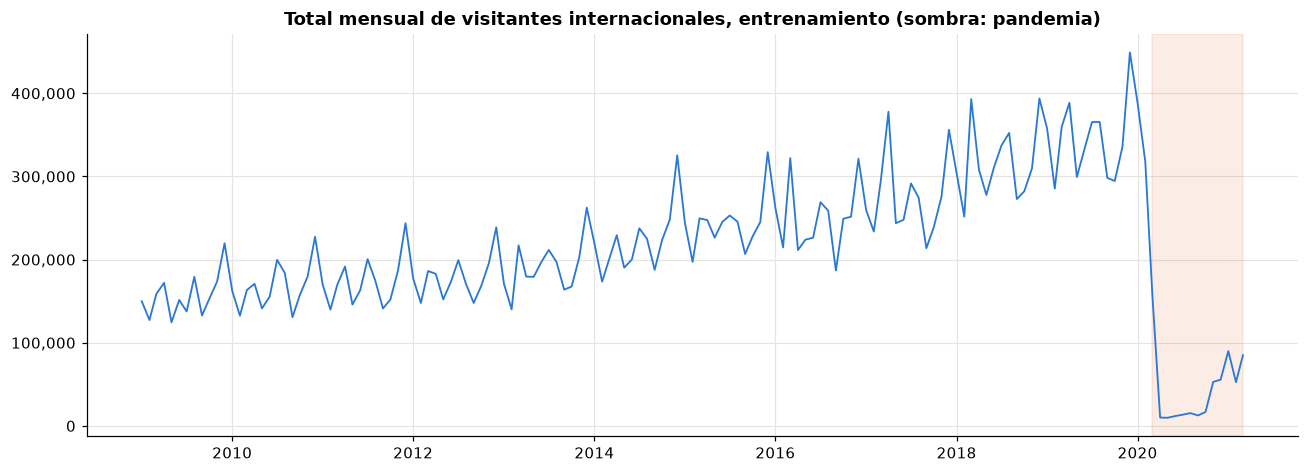

In [6]:
total = train["total"]
print(f"Inicio     : {total.index.min():%Y-%m}")
print(f"Fin        : {total.index.max():%Y-%m}")
print(f"Frecuencia : mensual ({total.index.freqstr}), {len(total)} observaciones")
print(f"Media      : {total.mean():,.0f} visitantes/mes | CV = {total.std() / total.mean():.2f}")
print(f"Máximo     : {total.max():,.0f} en {total.idxmax():%Y-%m}")
print(f"Mínimo     : {total.min():,.0f} en {total.idxmin():%Y-%m}")
graficar_serie(total, "Total mensual de visitantes internacionales, entrenamiento (sombra: pandemia)",
               "serie-total")

El gráfico muestra dos cosas. Hasta 2019 hay **tendencia creciente sostenida**: de unos 170 mil
visitantes mensuales al inicio a más de 340 mil en 2019. Encima hay un **patrón estacional que
se repite cada año**, con el pico de diciembre visible a simple vista y un máximo histórico de
449 mil en diciembre de 2019. La amplitud de las oscilaciones crece junto con el nivel, primer
indicio de estacionalidad multiplicativa.

En marzo de 2020 el cierre de fronteras hunde la serie de 344 mil visitantes promedio en 2019 a
9,779 en mayo de 2020, una caída del 97%. Los últimos doce meses del entrenamiento son ese piso
y el arranque de la recuperación (85 mil en marzo 2021). El quiebre no es un atípico a depurar,
es un cambio real de régimen, y va a dominar cualquier prueba estadística sobre la serie
completa.

### 2.2 Media y desviación móviles

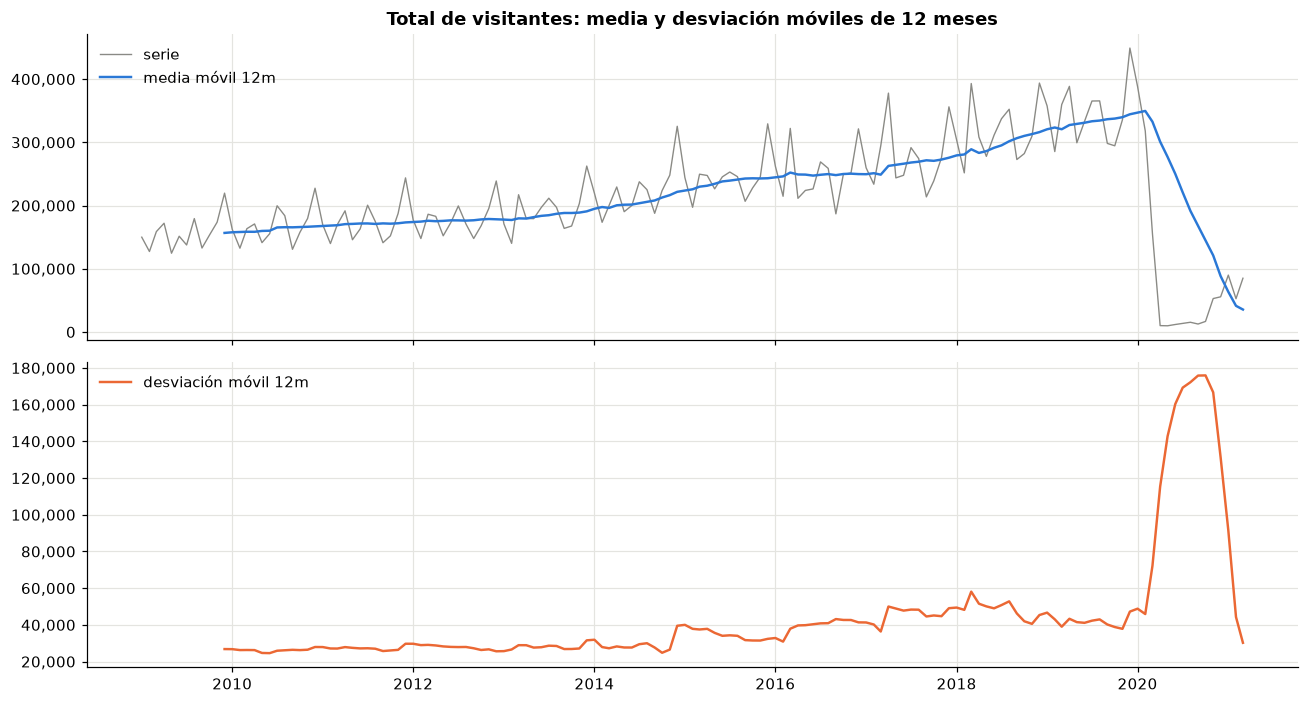

In [7]:
graficar_moviles(total, "Total de visitantes: media y desviación móviles de 12 meses", "serie-total-moviles")

La media móvil de 12 meses sube casi monótonamente durante once años y se desploma en 2020. La
media depende del tiempo, así que **no hay estacionariedad en media**. La desviación móvil crece
de unos 30 mil en la primera mitad prepandemia a unos 60 mil en la segunda, se duplica igual que
el nivel, y explota en 2020. Varianza que crece con el nivel significa serie **no estacionaria
en varianza**, y el remedio estándar es el logaritmo.

### 2.3 Descomposición

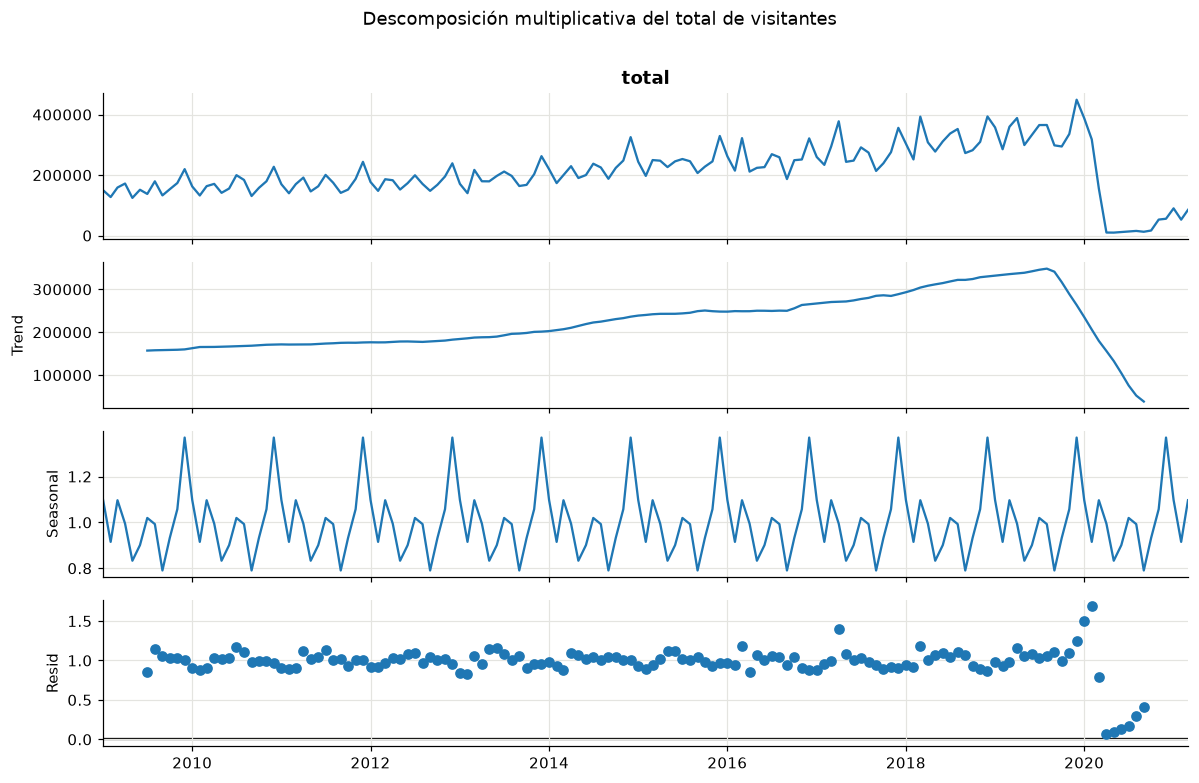

,residuo aditivo (rel. al nivel medio),residuo multiplicativo (rel. a 1)
desv. estándar relativa (prepandemia),0.0761,0.0665


In [8]:
desc_total, comparacion = descomponer(total, "Descomposición multiplicativa del total de visitantes",
                                      "serie-total-descomposicion")
comparacion

La **tendencia** reproduce lo que ya vimos: crecimiento sostenido y colapso. El componente
**estacional** es estable y de amplitud considerable: diciembre corre un 30% arriba del mes
promedio, febrero y septiembre un 18% abajo. El **residuo** multiplicativo se mantiene alrededor
de 1 en todo el tramo prepandemia y solo se dispara en 2020, donde ninguna descomposición con
estacionalidad fija puede seguir a la serie.

Graficamos la multiplicativa porque la amplitud estacional crece con el nivel. La comparación
numérica sobre el tramo prepandemia da residuos relativos de 7.6% para la aditiva y 7.0% para la
multiplicativa, ventaja para la multiplicativa.

Conclusión sobre estacionariedad: **no hay estacionariedad en media** (la tendencia domina la
serie) **ni en varianza** (la amplitud estacional y la dispersión crecen con el nivel). La serie
tiene **estacionalidad anual fuerte**, así que cualquier modelo tendrá que ser estacional con
período 12.

### 2.4 Transformación

**Sí es necesario transformar la serie.** La desviación móvil se duplica junto con el nivel y la
estacionalidad es multiplicativa: aplicamos el logaritmo para estabilizar la varianza y volver
aditiva la estacionalidad. La serie no tiene ceros (mínimo 9,779), así que el logaritmo es
directo.

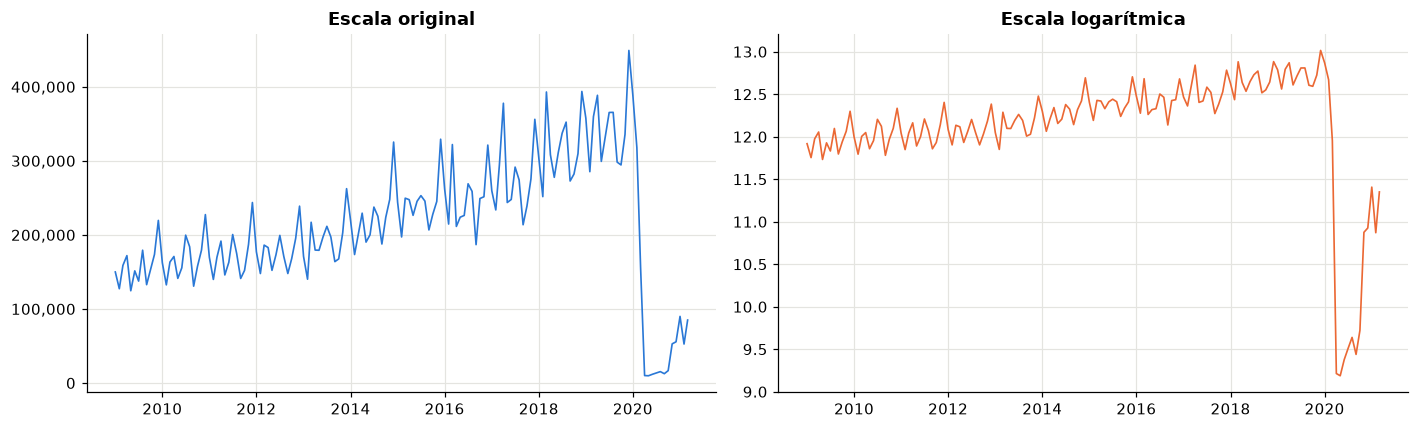

In [9]:
total_log = np.log(total)
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
ejes[0].plot(total, color=AZUL, lw=1.1)
ejes[0].set_title("Escala original")
miles(ejes[0])
ejes[1].plot(total_log, color=NARANJA, lw=1.1)
ejes[1].set_title("Escala logarítmica")
guardar("serie-total-log")
plt.show()

En escala logarítmica las oscilaciones estacionales tienen amplitud casi constante en todo el
tramo prepandemia: la varianza queda estabilizada. El colapso de 2020 se ve más profundo porque
en términos relativos lo fue. La tendencia sigue ahí: el logaritmo arregla la varianza, no la
media.

### 2.5 Estacionariedad en media: ACF, ADF y diferenciación

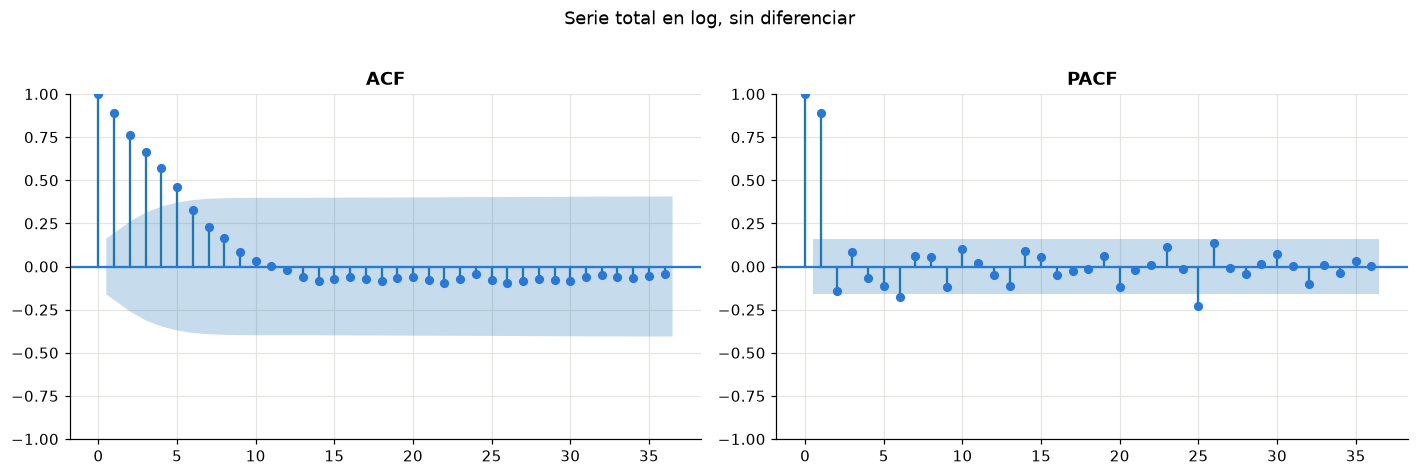

In [10]:
correlogramas(total_log, "Serie total en log, sin diferenciar", "serie-total-acf-nivel")

La ACF **decae muy lentamente**: 0.89 en el rezago 1 y todavía 0.33 seis meses después. Cada
observación está dominada por el nivel de la tendencia, no por dinámica de corto plazo. En una
serie estacionaria la ACF cae rápido a cero; aquí tarda más de un año. Ese decaimiento lento es
la evidencia gráfica de la no estacionariedad en media. La PACF concentra casi todo en el primer
rezago, el patrón típico de una serie que necesita diferenciarse.

Lo corroboramos con las pruebas formales sobre cada transformación:

In [11]:
tabla_estacionariedad(total_log, {
    "nivel (log)": total_log,
    "1a diferencia": total_log.diff(),
    "1a diferencia + estacional (12)": total_log.diff().diff(12),
})

,ADF estadístico,ADF p-valor,ADF veredicto,KPSS estadístico,KPSS p-valor,KPSS veredicto
nivel (log),-2.499,0.1156,NO estacionaria,0.175,0.1,estacionaria
1a diferencia,-3.085,0.0277,estacionaria,0.051,0.1,estacionaria
1a diferencia + estacional (12),-6.539,0.0,estacionaria,0.037,0.1,estacionaria


La prueba de Dickey-Fuller aumentada no rechaza la raíz unitaria en el nivel (p = 0.12): la
serie **no es estacionaria en media**. Para hacerla estacionaria hay que **diferenciarla una
vez** (d = 1). Con la primera diferencia el ADF ya rechaza (p = 0.028) y el KPSS no encuentra
evidencia contra la estacionariedad.

Falta el componente estacional. En la ACF de la primera diferencia (abajo) los rezagos 12 y 24
siguen positivos y significativos (0.19 y 0.27): la diferencia regular no eliminó la
estacionalidad anual. Aplicamos además una **diferencia estacional** (D = 1, período 12) y el
ADF rechaza con holgura (p < 0.0001). La serie requiere **una diferenciación regular y una
estacional** para ser estacionaria en media.

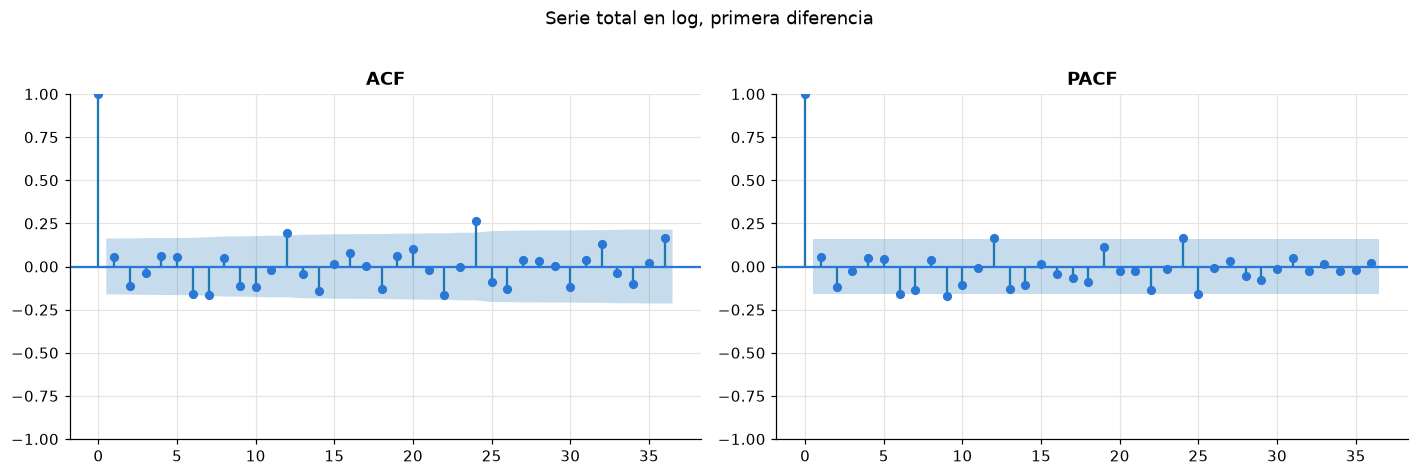

In [12]:
correlogramas(total_log.diff(), "Serie total en log, primera diferencia", "serie-total-acf-diff1")

### 2.6 Correlogramas de la serie estacionaria: candidatos p, d, q

Sobre la serie ya estacionaria (log, d = 1, D = 1) leemos la ACF para proponer q y la PACF para
proponer p.

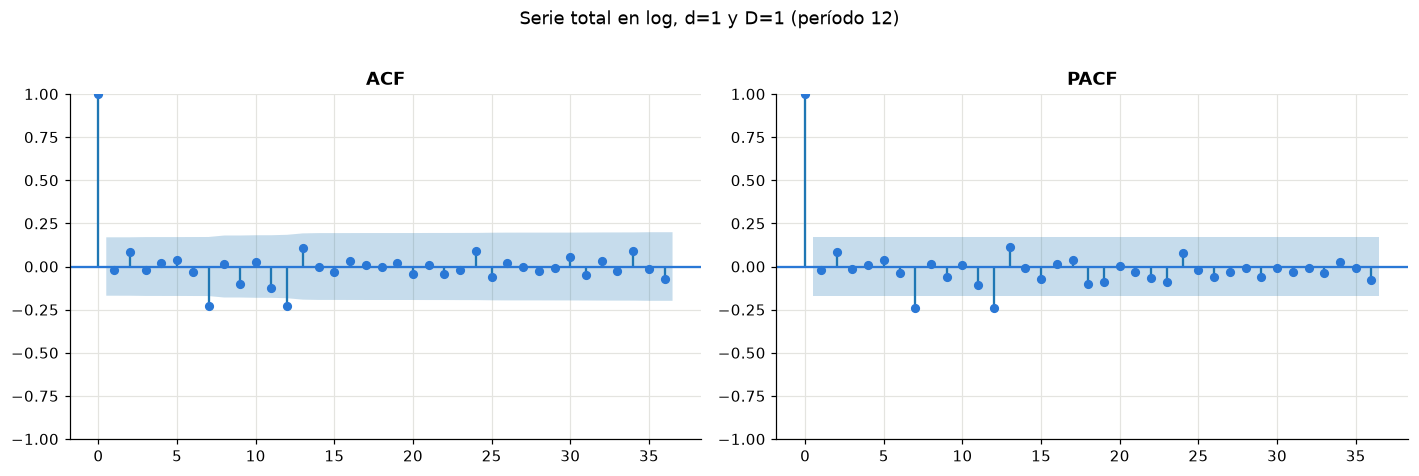

In [13]:
total_estacionaria = total_log.diff().diff(12)
correlogramas(total_estacionaria, "Serie total en log, d=1 y D=1 (período 12)", "serie-total-acf-estacionaria")

Los correlogramas quedan casi limpios. En los primeros rezagos ninguno es claramente
significativo. Los únicos que cruzan la banda son el 7, marginal y sin lectura estacional
natural, y el **12, negativo en ambas funciones** (-0.23 en la ACF, -0.27 en la PACF), la firma
de un componente de media móvil estacional.

Lectura preliminar para el modelado: **d = 1, D = 1, s = 12** sobre la serie en logaritmo. El
rezago 12 negativo en la ACF sugiere **Q = 1** y la ausencia de rezagos regulares significativos
sugiere órdenes regulares bajos, p y q en {0, 1}. El candidato inicial es un
**SARIMA(0,1,1)(0,1,1)₁₂**, la estructura del clásico modelo "airline". En la fase de modelado
lo compararemos contra variantes cercanas (p = 1, P = 1) por AIC/BIC y análisis de residuos, y
contra auto_arima como verificación externa.

## 3. Serie regional: América Del Centro

### 3.1 Inicio, fin, frecuencia y primer vistazo

Misma cobertura que la serie total: **enero 2009 a marzo 2021** en entrenamiento, **frecuencia
mensual**, 147 observaciones sin huecos. Es la región de `region_dos` con mayor acumulado, 33.3
millones de visitantes en el período completo, el 73% del total. Por ese peso hereda buena parte
de la forma de la serie total; las diferencias son lo interesante.

Inicio     : 2009-01
Fin        : 2021-03
Frecuencia : mensual (MS), 147 observaciones
Media      : 157,387 visitantes/mes | CV = 0.45
Máximo     : 359,173 en 2019-12
Mínimo     : 9,779 en 2020-05


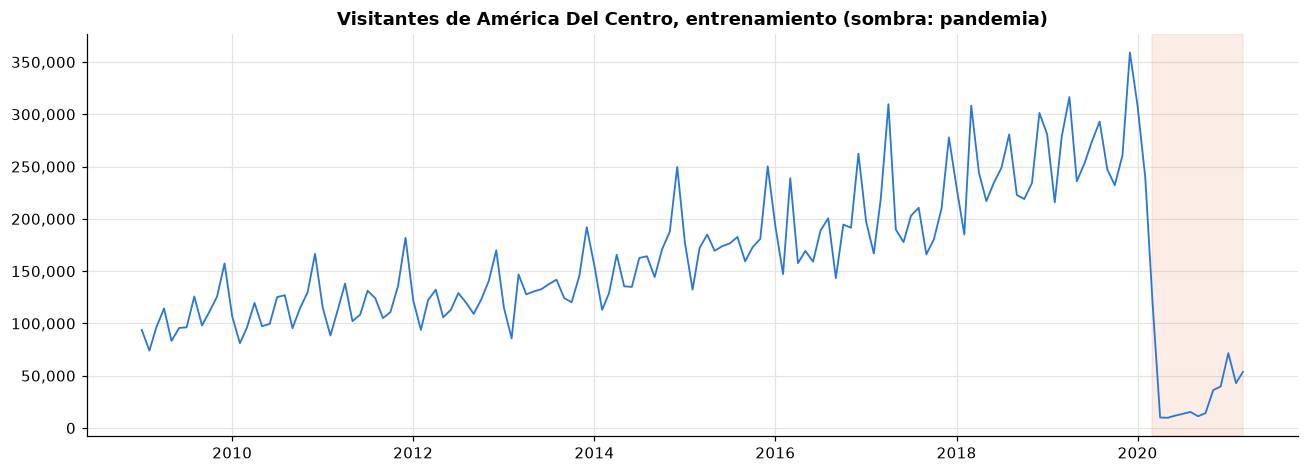

In [14]:
centro = train["region: América Del Centro"]
print(f"Inicio     : {centro.index.min():%Y-%m}")
print(f"Fin        : {centro.index.max():%Y-%m}")
print(f"Frecuencia : mensual ({centro.index.freqstr}), {len(centro)} observaciones")
print(f"Media      : {centro.mean():,.0f} visitantes/mes | CV = {centro.std() / centro.mean():.2f}")
print(f"Máximo     : {centro.max():,.0f} en {centro.idxmax():%Y-%m}")
print(f"Mínimo     : {centro.min():,.0f} en {centro.idxmin():%Y-%m}")
graficar_serie(centro, "Visitantes de América Del Centro, entrenamiento (sombra: pandemia)",
               "serie-centro")

La serie repite la anatomía del total: crecimiento hasta 2019, pico de 359 mil en diciembre
2019, colapso a 9,779 en mayo 2020. Tiene dos rasgos propios. Primero, es **más volátil** que el
total (coeficiente de variación 0.45 contra 0.41): la demanda centroamericana reacciona más
fuerte, al alza en diciembre y a la baja en los valles. Segundo, su recuperación al cierre del
entrenamiento es **más lenta**: en marzo 2021 lleva 54 mil visitantes contra un promedio 2019 de
271 mil, el 20%, mientras el total ya recuperaba el 25%. La diferencia es el mercado
norteamericano, que reabrió antes que las fronteras terrestres de la región.

### 3.2 Media y desviación móviles

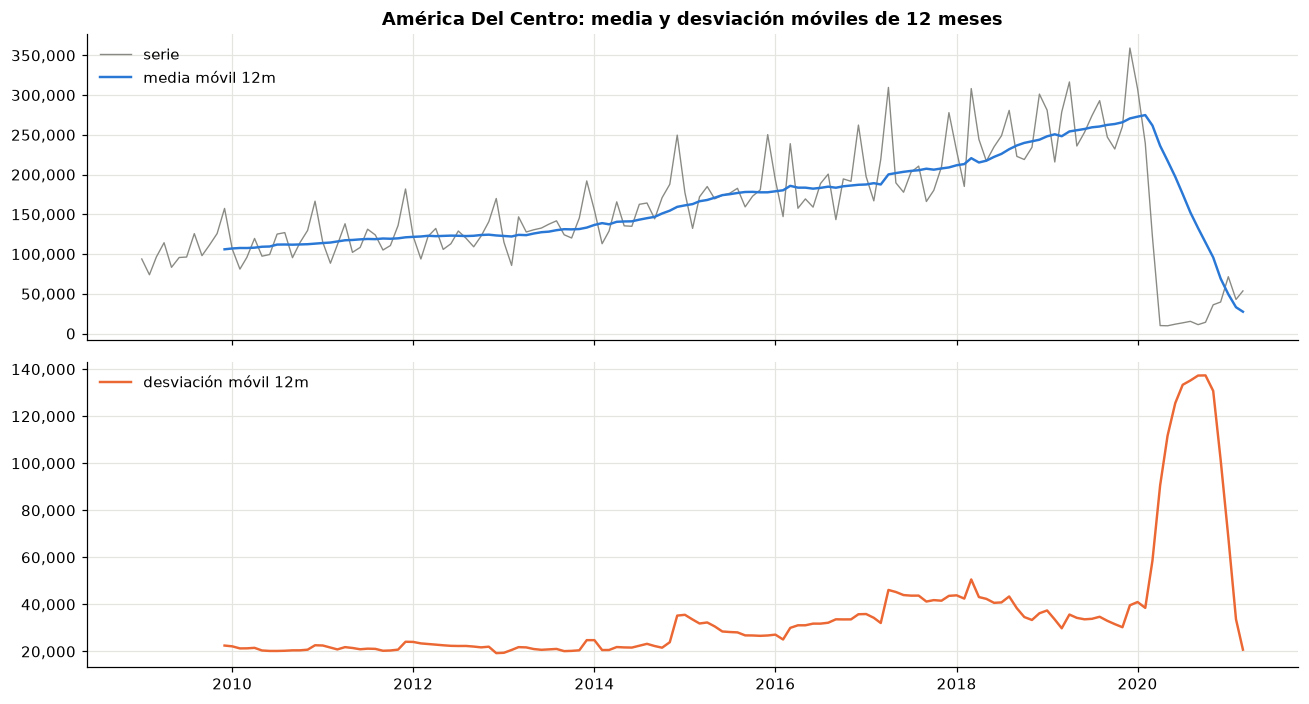

In [15]:
graficar_moviles(centro, "América Del Centro: media y desviación móviles de 12 meses", "serie-centro-moviles")

El patrón es el mismo del total y la conclusión también. Media móvil creciente once años y
desplomada en 2020: **no estacionaria en media**. Desviación móvil que sube de 24 mil a 52 mil
entre las dos mitades del tramo prepandemia, otra vez duplicándose junto con la media: **no
estacionaria en varianza**.

### 3.3 Descomposición

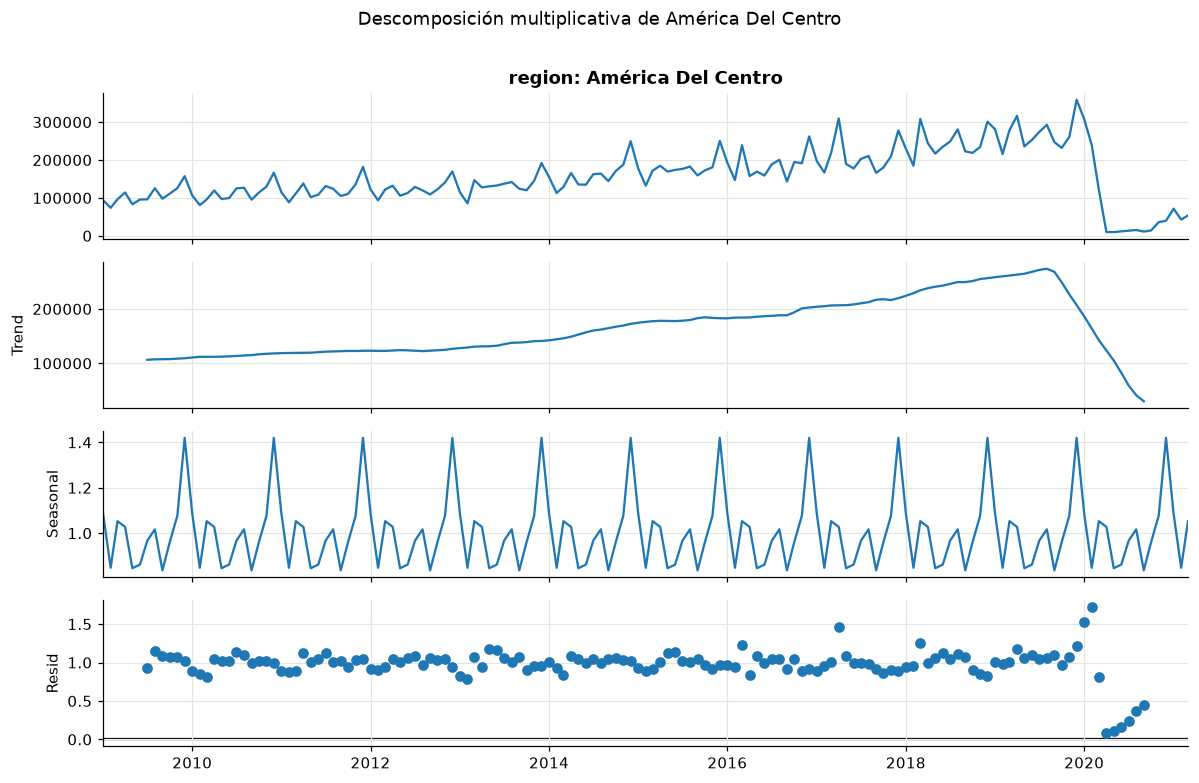

,residuo aditivo (rel. al nivel medio),residuo multiplicativo (rel. a 1)
desv. estándar relativa (prepandemia),0.0947,0.0819


In [16]:
desc_centro, comparacion_centro = descomponer(centro, "Descomposición multiplicativa de América Del Centro",
                                              "serie-centro-descomposicion")
comparacion_centro

La estacionalidad de América Del Centro es **más pronunciada que la del total**: diciembre corre
un 39% arriba del mes promedio (contra 34% del total) y febrero un 25% abajo (contra 19%). El
patrón está dominado por los viajes de fin de año, consistente con una región donde pesa la
visita familiar además del turismo. El residuo multiplicativo prepandemia (8%) vuelve a ganarle
al aditivo (9.5%). Conclusión igual que el total: **no estacionaria ni en media ni en
varianza**, con estacionalidad anual fuerte que obliga a modelos de período 12.

### 3.4 Transformación y estacionariedad en media

La serie **necesita logaritmo** por lo mismo que el total: varianza proporcional al nivel,
estacionalidad multiplicativa y mínimo positivo (9,779). Sobre el log corremos el mismo
diagnóstico de estacionariedad en media.

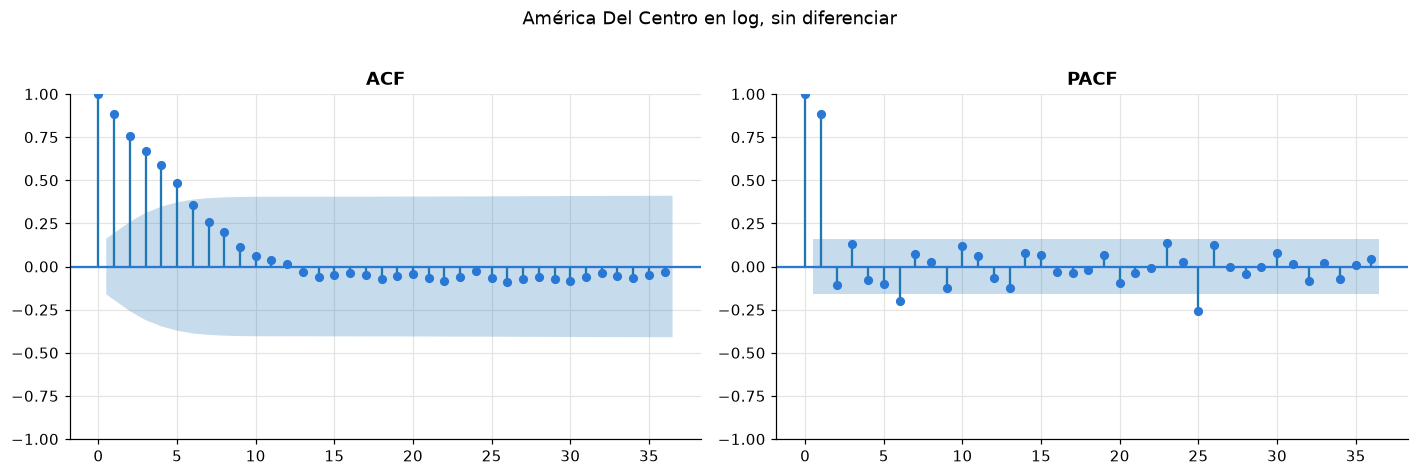

,ADF estadístico,ADF p-valor,ADF veredicto,KPSS estadístico,KPSS p-valor,KPSS veredicto
nivel (log),-2.216,0.2003,NO estacionaria,0.181,0.1,estacionaria
1a diferencia,-2.991,0.0358,estacionaria,0.073,0.1,estacionaria
1a diferencia + estacional (12),-6.274,0.0,estacionaria,0.042,0.1,estacionaria


In [17]:
centro_log = np.log(centro)
correlogramas(centro_log, "América Del Centro en log, sin diferenciar", "serie-centro-acf-nivel")
tabla_estacionariedad(centro_log, {
    "nivel (log)": centro_log,
    "1a diferencia": centro_log.diff(),
    "1a diferencia + estacional (12)": centro_log.diff().diff(12),
})

La ACF del nivel decae tan lento como la del total (0.88 en el rezago 1, 0.35 en el 6): **no es
estacionaria en media**. El ADF lo corrobora, no rechaza la raíz unitaria en el nivel (p = 0.20).
Con **una diferencia regular** el ADF ya rechaza (p = 0.036). En la ACF de la primera diferencia
quedan rezagos estacionales significativos (0.25 en el 12, 0.31 en el 24), así que aplicamos la
**diferencia estacional** y el rechazo es contundente (p < 0.0001). Igual que el total:
**d = 1 y D = 1**.

### 3.5 Correlogramas de la serie estacionaria

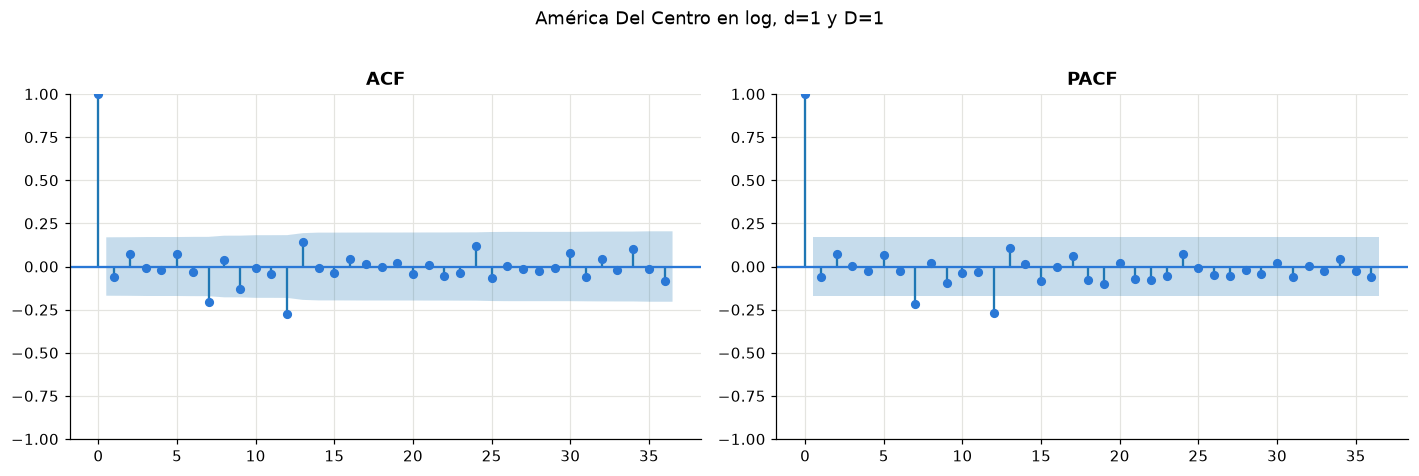

In [18]:
centro_estacionaria = centro_log.diff().diff(12)
correlogramas(centro_estacionaria, "América Del Centro en log, d=1 y D=1", "serie-centro-acf-estacionaria")

El patrón calca el de la serie total: rezagos regulares sin estructura clara (solo el 7
marginal) y **rezago 12 negativo y significativo en ambas funciones** (-0.28 en la ACF, -0.30 en
la PACF). Los candidatos son los mismos: **SARIMA(0,1,1)(0,1,1)₁₂** sobre el log como punto de
partida, con p y q en {0, 1} y P en {0, 1} a comparar por AIC/BIC. Que la región dominante
reproduzca la estructura del total es esperable, es el 73% de la serie. Las diferencias de
desempeño entre ambos modelos van a venir del 27% restante.

## 4. Serie de frontera: La Aurora

### 4.1 Inicio, fin, frecuencia y primer vistazo

Igual que las anteriores: **enero 2009 a marzo 2021**, **frecuencia mensual**, 147 observaciones
sin huecos. La Aurora es el aeropuerto internacional de la capital y el punto de ingreso con
mayor acumulado, 19 millones de visitantes en el período completo. Es la única serie de las tres
puramente aérea, y eso le da una dinámica propia que la vuelve el mejor contraste del grupo.

Inicio     : 2009-01
Fin        : 2021-03
Frecuencia : mensual (MS), 147 observaciones
Media      : 88,860 visitantes/mes | CV = 0.33
Máximo     : 157,465 en 2019-12
Mínimo     : 484 en 2020-04


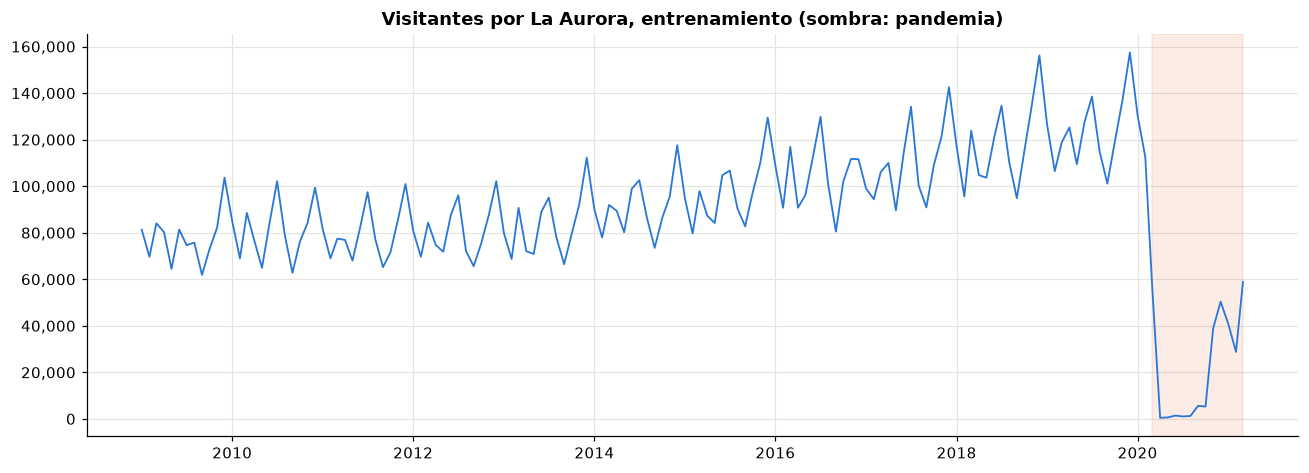

In [19]:
aurora = train["frontera: La Aurora"]
print(f"Inicio     : {aurora.index.min():%Y-%m}")
print(f"Fin        : {aurora.index.max():%Y-%m}")
print(f"Frecuencia : mensual ({aurora.index.freqstr}), {len(aurora)} observaciones")
print(f"Media      : {aurora.mean():,.0f} visitantes/mes | CV = {aurora.std() / aurora.mean():.2f}")
print(f"Máximo     : {aurora.max():,.0f} en {aurora.idxmax():%Y-%m}")
print(f"Mínimo     : {aurora.min():,.0f} en {aurora.idxmin():%Y-%m}")
graficar_serie(aurora, "Visitantes por La Aurora, entrenamiento (sombra: pandemia)", "serie-aurora")

Tres rasgos distinguen a La Aurora. Es la **más estable** de las tres series (coeficiente de
variación 0.33 contra 0.41 del total): el tráfico aéreo crece más gradual, la media prepandemia
pasa de 80 mil a 107 mil entre mitades, un 33% contra el 59% del total. Su **estacionalidad
tiene otro calendario**: además del pico de diciembre (+28%) hay un pico de julio (+16%) que las
series terrestres no tienen, consistente con el verano del hemisferio norte, y el valle más
profundo es septiembre (-19%), no febrero. Y su **colapso pandémico fue el más extremo**: con el
aeropuerto cerrado, abril 2020 registra 484 visitantes contra un promedio 2019 de 123 mil, una
caída del 99.6%. También rebota más rápido: en marzo 2021 ya recupera el 48% de su nivel 2019,
contra 25% del total.

### 4.2 Media y desviación móviles

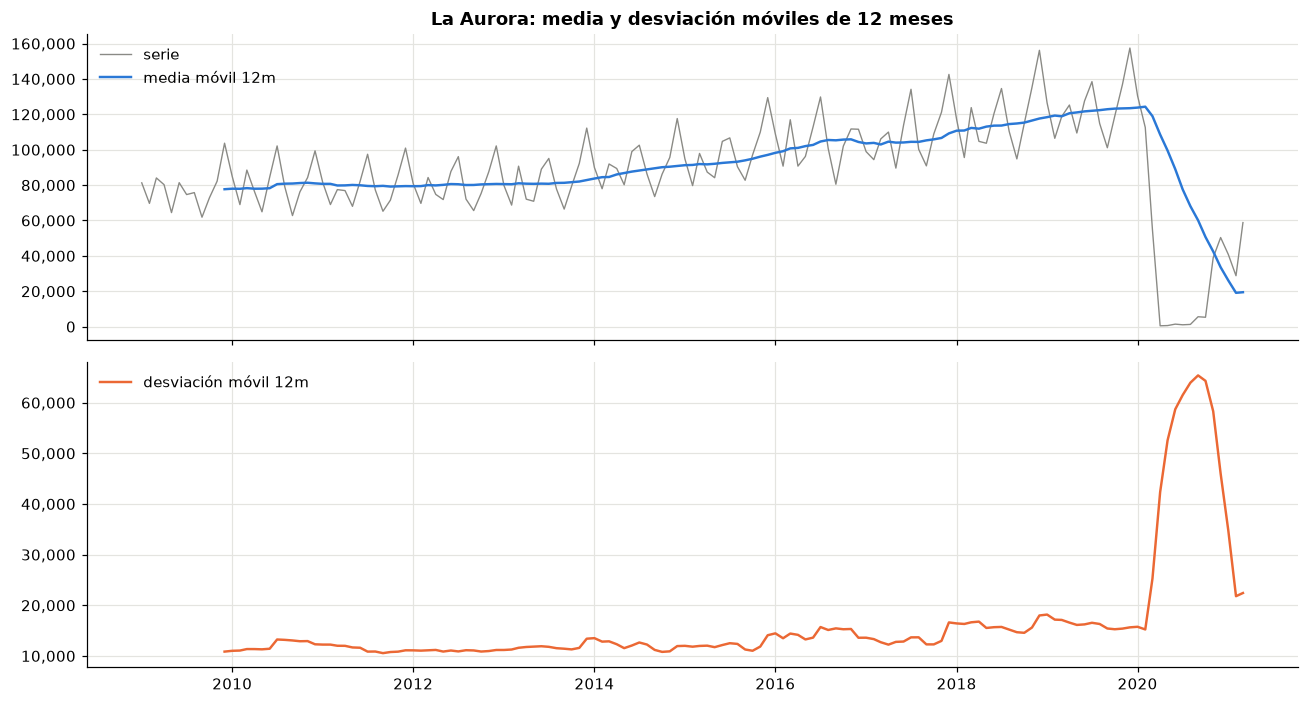

In [20]:
graficar_moviles(aurora, "La Aurora: media y desviación móviles de 12 meses", "serie-aurora-moviles")

Mismo veredicto con pendientes más suaves. Media móvil creciente y desplomada en 2020: **no
estacionaria en media**. Desviación móvil que acompaña al nivel, de 12 mil a 18 mil entre
mitades prepandemia: **no estacionaria en varianza**, aunque la varianza crece menos que en las
otras dos series, coherente con su perfil más estable.

### 4.3 Descomposición

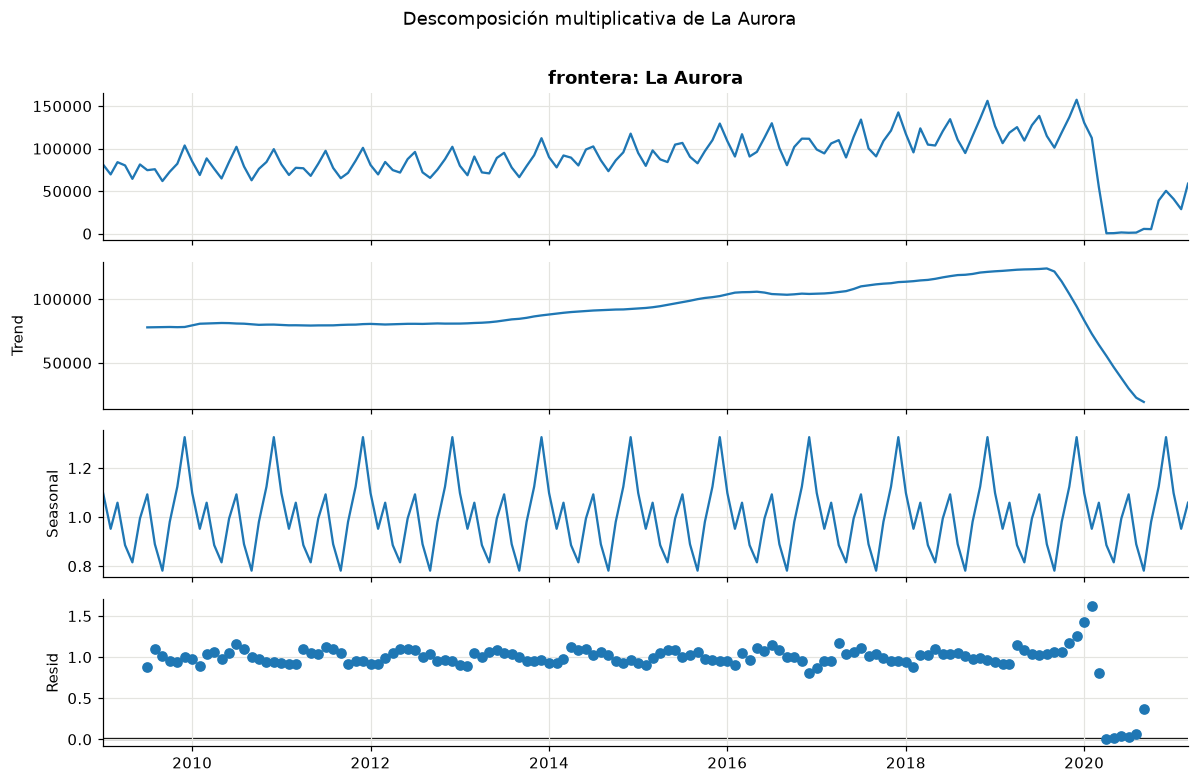

,residuo aditivo (rel. al nivel medio),residuo multiplicativo (rel. a 1)
desv. estándar relativa (prepandemia),0.0457,0.0402


In [21]:
desc_aurora, comparacion_aurora = descomponer(aurora, "Descomposición multiplicativa de La Aurora",
                                              "serie-aurora-descomposicion")
comparacion_aurora

La descomposición confirma el doble pico de diciembre y julio, y un residuo prepandemia
notablemente más limpio que el de las otras series (4.6% aditivo, 4.4% multiplicativo): el
tráfico aéreo es más predecible mes a mes que el terrestre. La ventaja del modelo multiplicativo
es más estrecha porque la amplitud estacional crece menos, pero existe, y el logaritmo además
ayuda con el colapso de 2020, que en esta serie es el más violento. Conclusión: **no
estacionaria en media ni en varianza**, estacionalidad anual clara con calendario propio.

### 4.4 Transformación y estacionariedad en media

Aplicamos el logaritmo (mínimo 484, sin ceros) y corremos el diagnóstico.

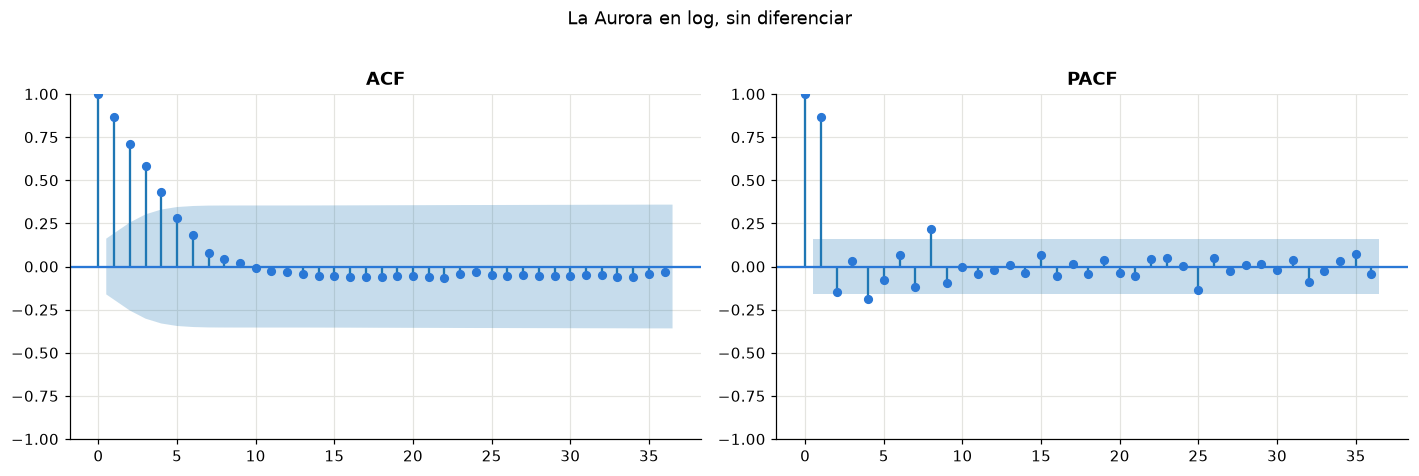

,ADF estadístico,ADF p-valor,ADF veredicto,KPSS estadístico,KPSS p-valor,KPSS veredicto
nivel (log),-2.032,0.2726,NO estacionaria,0.254,0.1,estacionaria
1a diferencia,-3.095,0.0269,estacionaria,0.024,0.1,estacionaria
1a diferencia + estacional (12),-6.213,0.0,estacionaria,0.033,0.1,estacionaria


In [22]:
aurora_log = np.log(aurora)
correlogramas(aurora_log, "La Aurora en log, sin diferenciar", "serie-aurora-acf-nivel")
tabla_estacionariedad(aurora_log, {
    "nivel (log)": aurora_log,
    "1a diferencia": aurora_log.diff(),
    "1a diferencia + estacional (12)": aurora_log.diff().diff(12),
})

Otra vez la ACF de decaimiento lento (0.86 en el rezago 1) y un ADF que no rechaza la raíz
unitaria en el nivel (p = 0.27): **no estacionaria en media**. Se corrige con **una diferencia
regular** (ADF p = 0.027 tras d = 1).

La diferencia con las otras series está en el componente estacional. Tras la primera diferencia,
los rezagos 12 y 24 de la ACF quedan en 0.07 y 0.11, por debajo del umbral de significancia. La
huella estacional en la autocorrelación es más débil aquí, en parte porque el colapso de 2020
pesa mucho en la estimación. La estacionalidad existe (el índice de diciembre es 128) y la serie
doblemente diferenciada rechaza el ADF con holgura, pero la diferencia estacional no es tan
obligatoria como en el total. En el modelado compararemos las dos rutas, D = 1 y D = 0 con
componente estacional en el modelo, y decidirán AIC/BIC y los residuos.

### 4.5 Correlogramas de la serie estacionaria

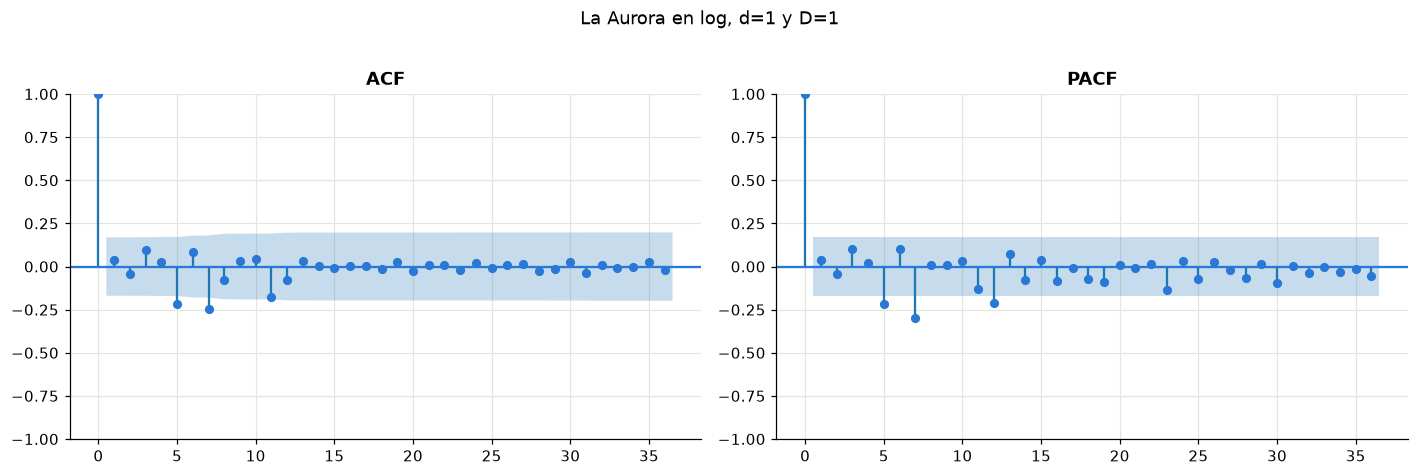

In [23]:
aurora_estacionaria = aurora_log.diff().diff(12)
correlogramas(aurora_estacionaria, "La Aurora en log, d=1 y D=1", "serie-aurora-acf-estacionaria")

Los correlogramas de La Aurora son menos limpios que los de las otras dos series: aparecen
rezagos negativos marginales en 5 y 7, y el 12 vuelve a ser negativo y significativo en la PACF
(-0.23). La lectura preliminar es la misma familia, **Q = 1 estacional con órdenes regulares
bajos**, pero con más incertidumbre en la parte regular: probaremos p y q en {0, 1, 2} además de
las variantes de D. Es la serie donde más valor va a tener contrastar nuestra propuesta manual
contra auto_arima.

## 5. Serie de frontera: Valle Nuevo

### 5.1 Inicio, fin, frecuencia y primer vistazo

Misma cobertura que las anteriores: **enero 2009 a marzo 2021** en entrenamiento, **frecuencia
mensual**, 147 observaciones sin huecos. Valle Nuevo es la frontera terrestre con El Salvador y
el segundo punto de ingreso por acumulado. Es el contraste natural de La Aurora: mismo rango de
fechas, pero dinámica puramente terrestre.

Inicio     : 2009-01
Fin        : 2021-03
Frecuencia : mensual (MS), 147 observaciones
Media      : 48,633 visitantes/mes | CV = 0.50
Máximo     : 111,142 en 2019-12
Mínimo     : 80 en 2020-12


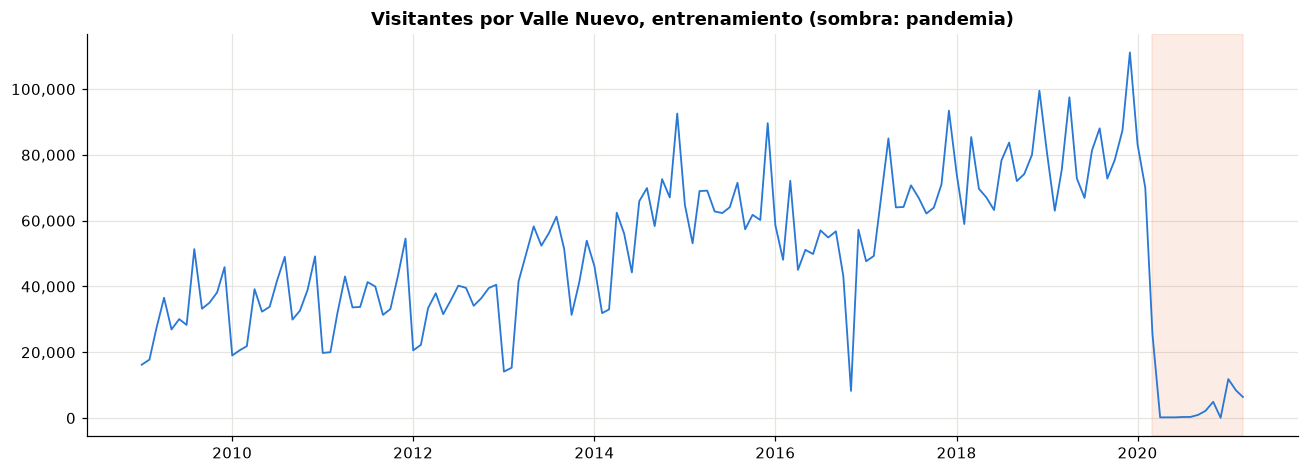

In [24]:
vnuevo = train["frontera: Valle Nuevo"]
print(f"Inicio     : {vnuevo.index.min():%Y-%m}")
print(f"Fin        : {vnuevo.index.max():%Y-%m}")
print(f"Frecuencia : mensual ({vnuevo.index.freqstr}), {len(vnuevo)} observaciones")
print(f"Media      : {vnuevo.mean():,.0f} visitantes/mes | CV = {vnuevo.std() / vnuevo.mean():.2f}")
print(f"Máximo     : {vnuevo.max():,.0f} en {vnuevo.idxmax():%Y-%m}")
print(f"Mínimo     : {vnuevo.min():,.0f} en {vnuevo.idxmin():%Y-%m}")
graficar_serie(vnuevo, "Visitantes por Valle Nuevo, entrenamiento (sombra: pandemia)", "serie-vnuevo")

Valle Nuevo creció más rápido que las series anteriores: la media mensual prepandemia pasa de 37
mil en la primera mitad a 68 mil en la segunda, un 85% contra el 33% de La Aurora. Su
estacionalidad es la típica del flujo salvadoreño: diciembre en el tope (índice 130), picos
secundarios en agosto (120) y Semana Santa (abril, 113), y el valle en febrero (69). Y su
pandemia es la más larga de las analizadas: el cierre terrestre la lleva a 201 visitantes en
abril 2020 (una caída del 99.8%) y el mínimo absoluto llega en diciembre 2020, con 80. Al cierre
del entrenamiento apenas recupera el 8% de su nivel 2019, contra 48% de La Aurora: la frontera
terrestre reabrió mucho después que el aeropuerto.

### 5.2 Media y desviación móviles

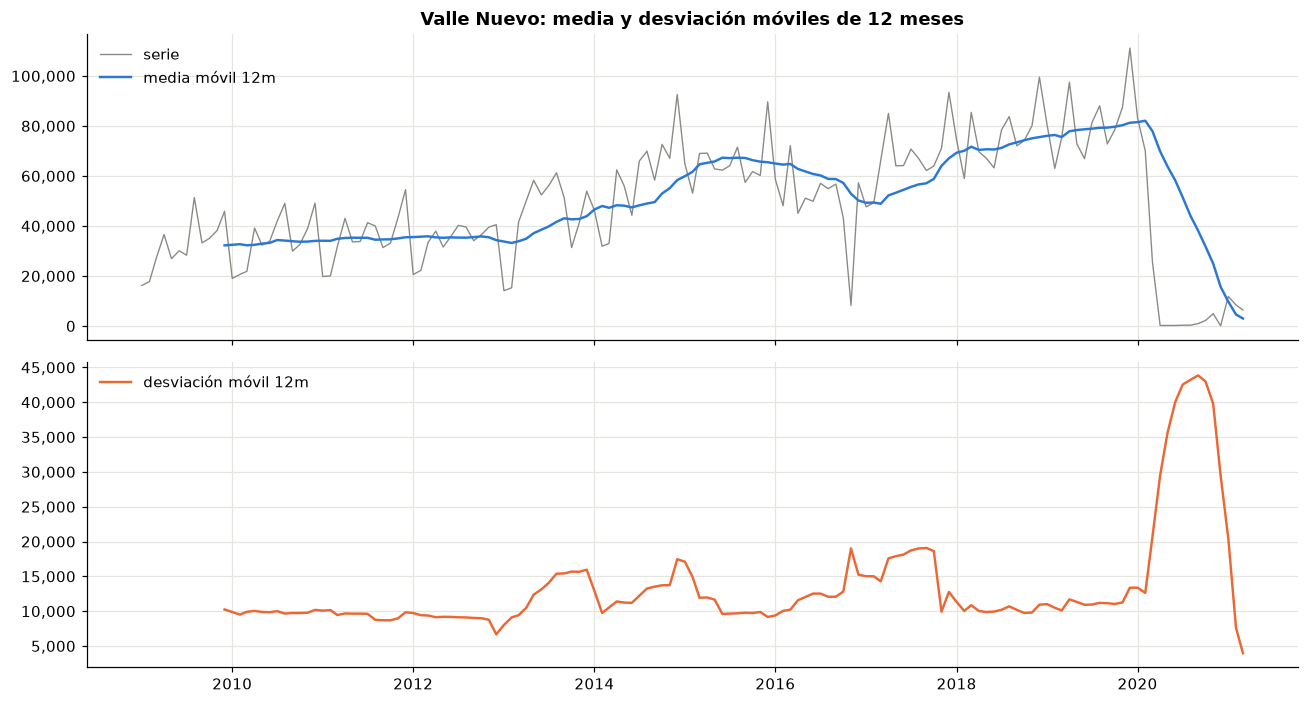

In [25]:
graficar_moviles(vnuevo, "Valle Nuevo: media y desviación móviles de 12 meses", "serie-vnuevo-moviles")

La media móvil sube 85% entre mitades prepandemia y se desploma en 2020: **no estacionaria en
media**. La varianza es menos concluyente que en las otras series: la desviación móvil
prepandemia solo sube de 10 mil a 12 mil mientras la media casi se duplica. La dispersión crece
con el nivel, pero menos que proporcionalmente.

### 5.3 Descomposición

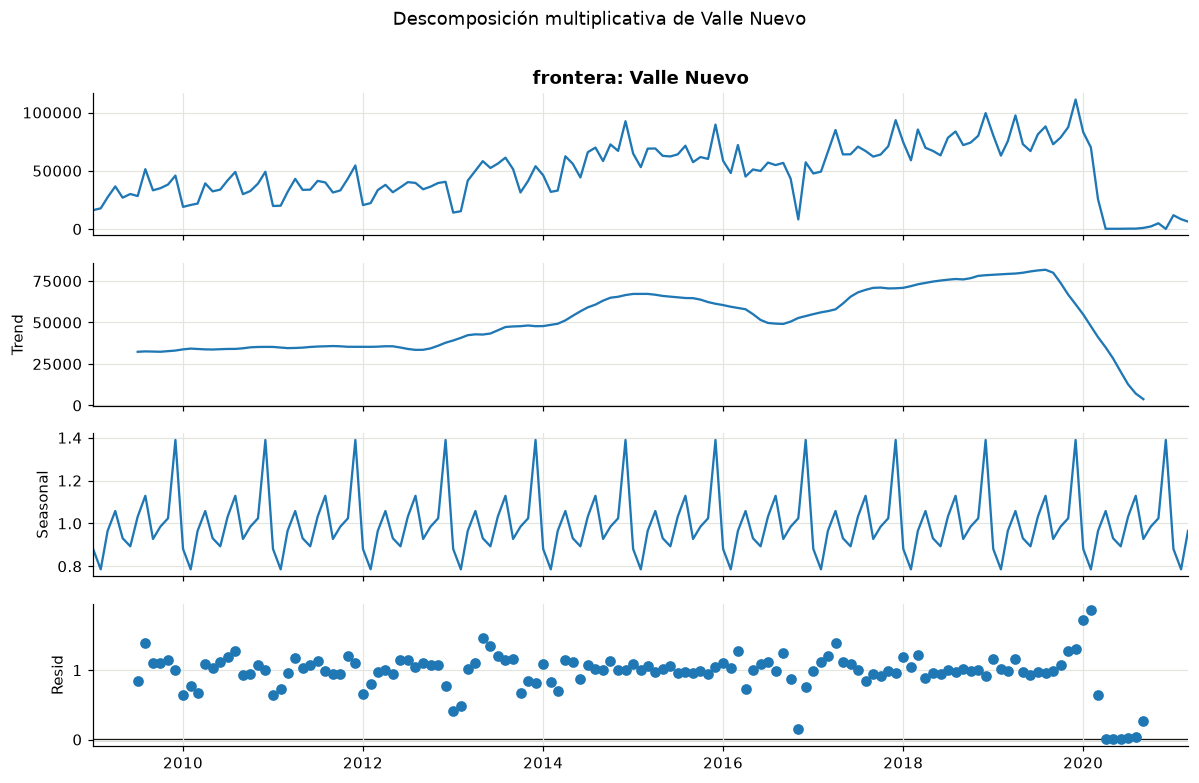

,residuo aditivo (rel. al nivel medio),residuo multiplicativo (rel. a 1)
desv. estándar relativa (prepandemia),0.1542,0.1808


In [26]:
desc_vnuevo, comparacion_vnuevo = descomponer(vnuevo, "Descomposición multiplicativa de Valle Nuevo",
                                              "serie-vnuevo-descomposicion")
comparacion_vnuevo

La descomposición confirma el calendario salvadoreño de tres picos (diciembre, agosto, Semana
Santa) y deja el residuo más ruidoso hasta ahora: 15.4% aditivo y 18.1% multiplicativo en el
tramo prepandemia. El flujo terrestre es mucho menos regular mes a mes que el aéreo (La Aurora
tenía 4.4%).

Aquí el residuo prepandemia favorece a la aditiva, al revés que en las series anteriores. Es
consistente con lo que mostró la desviación móvil: la amplitud estacional crece menos que el
nivel. Conclusión: **no estacionaria en media**; en varianza la evidencia es mixta, no
estacionaria pero con crecimiento débil de la dispersión.

### 5.4 Transformación

Aplicamos el logaritmo de todas formas, por dos razones. Primero, el colapso de 2020 lleva la
serie de 111 mil a 80 visitantes, tres órdenes de magnitud: en escala original ese tramo domina
cualquier ajuste, en log queda en una escala comparable al resto. Segundo, mantener las siete
series en la misma escala hace comparables los modelos y las métricas. La serie no tiene ceros
(mínimo 80), así que el logaritmo es directo. Que la ganancia sea menor que en las otras series
es un punto a revisar en el modelado.

### 5.5 Estacionariedad en media: ACF, ADF y diferenciación

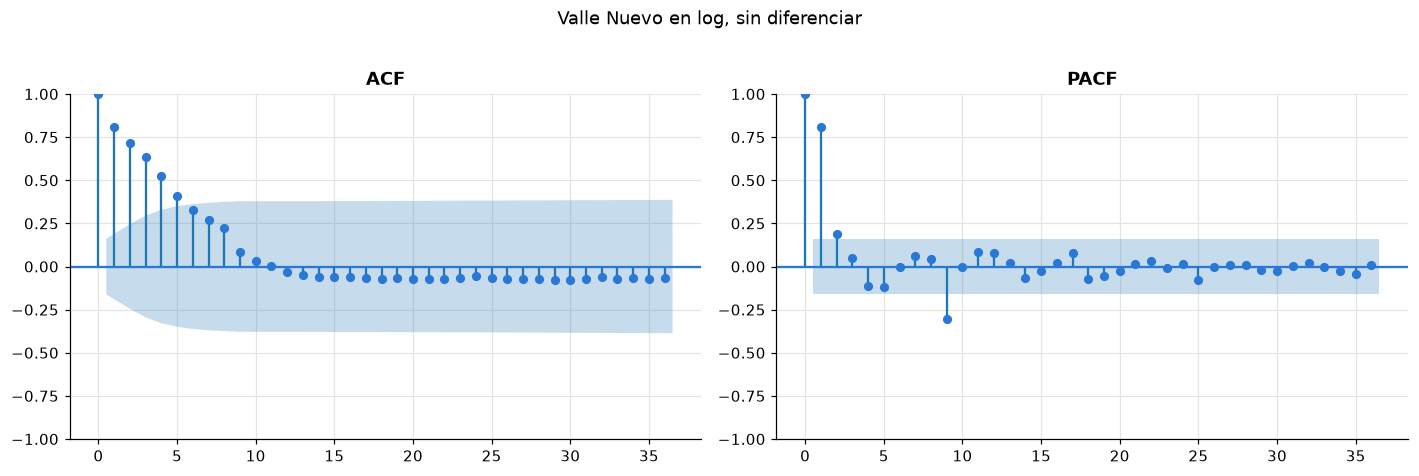

,ADF estadístico,ADF p-valor,ADF veredicto,KPSS estadístico,KPSS p-valor,KPSS veredicto
nivel (log),-2.231,0.1952,NO estacionaria,0.228,0.1,estacionaria
1a diferencia,-5.053,0.0,estacionaria,0.077,0.1,estacionaria
1a diferencia + estacional (12),-5.309,0.0,estacionaria,0.035,0.1,estacionaria


In [27]:
vnuevo_log = np.log(vnuevo)
correlogramas(vnuevo_log, "Valle Nuevo en log, sin diferenciar", "serie-vnuevo-acf-nivel")
tabla_estacionariedad(vnuevo_log, {
    "nivel (log)": vnuevo_log,
    "1a diferencia": vnuevo_log.diff(),
    "1a diferencia + estacional (12)": vnuevo_log.diff().diff(12),
})

La ACF del nivel decae lento (0.81 en el rezago 1, 0.33 en el 6) y el ADF no rechaza la raíz
unitaria (p = 0.20): **no estacionaria en media**. Con **una diferencia regular** el ADF rechaza
con contundencia (p < 0.0001): **d = 1** basta.

Tras la primera diferencia, los rezagos estacionales de la ACF quedan en 0.04 (12) y 0.06 (24),
lejos de la significancia. Igual que en La Aurora, la huella estacional en la autocorrelación es
débil pese a que los índices estacionales existen (diciembre 130). La diferencia estacional no
es obligatoria aquí; en el modelado compararemos D = 1 contra D = 0 con estacionalidad en el
modelo.

### 5.6 Correlogramas de la serie estacionaria

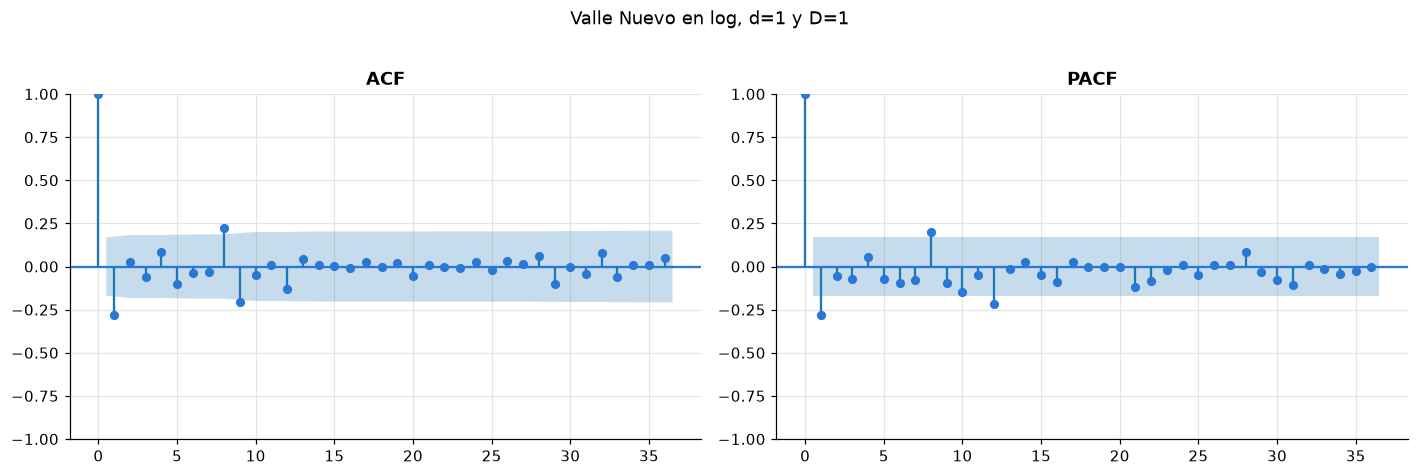

In [28]:
vnuevo_estacionaria = vnuevo_log.diff().diff(12)
correlogramas(vnuevo_estacionaria, "Valle Nuevo en log, d=1 y D=1", "serie-vnuevo-acf-estacionaria")

El rezago 1 es negativo y significativo en ambas funciones (-0.28), la firma de un término MA
regular: **q = 1**. En la parte estacional, la PACF marca el rezago 12 (-0.22) mientras la ACF
no, así que el componente estacional es más débil que en el total pero no descartable. Los
rezagos 8 y 9 rozan la banda sin lectura estacional natural; no los usamos para fijar órdenes.
Candidatos: **SARIMA(0,1,1)(0,1,1)₁₂** y su variante con D = 0, con p en {0, 1}.

## 6. Serie de frontera: San Cristóbal

### 6.1 Inicio, fin, frecuencia y primer vistazo

Misma cobertura: **enero 2009 a marzo 2021**, **frecuencia mensual**, 147 observaciones sin
huecos. San Cristóbal es la otra frontera terrestre con El Salvador y la tercera por acumulado.
De las cinco series analizadas es la más volátil, y la única donde la primera diferencia no
alcanza para la estacionariedad, como se ve abajo.

Inicio     : 2009-01
Fin        : 2021-03
Frecuencia : mensual (MS), 147 observaciones
Media      : 18,586 visitantes/mes | CV = 0.61
Máximo     : 53,127 en 2017-04
Mínimo     : 14 en 2020-12


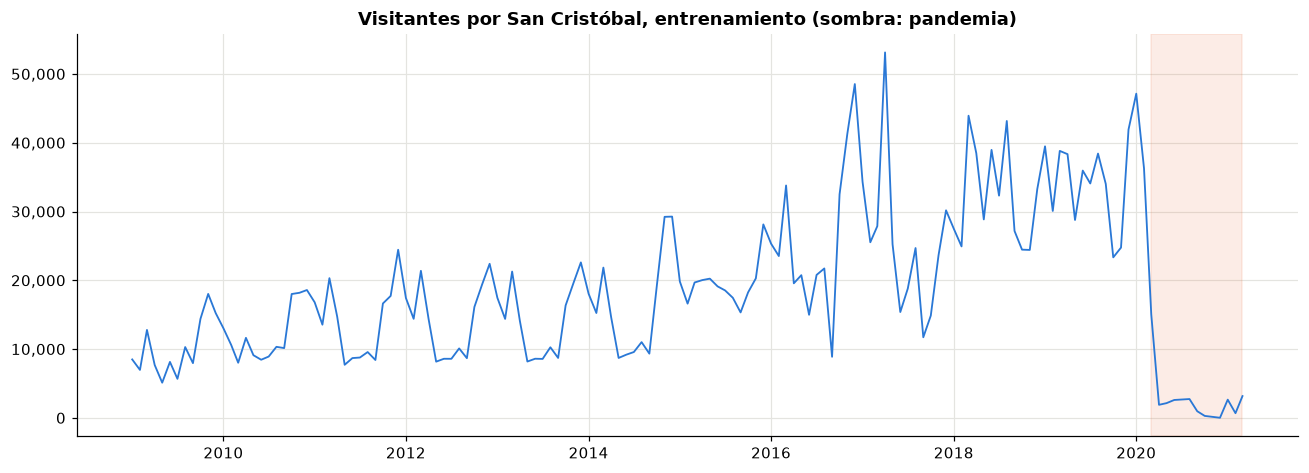

In [29]:
scristobal = train["frontera: San Cristóbal"]
print(f"Inicio     : {scristobal.index.min():%Y-%m}")
print(f"Fin        : {scristobal.index.max():%Y-%m}")
print(f"Frecuencia : mensual ({scristobal.index.freqstr}), {len(scristobal)} observaciones")
print(f"Media      : {scristobal.mean():,.0f} visitantes/mes | CV = {scristobal.std() / scristobal.mean():.2f}")
print(f"Máximo     : {scristobal.max():,.0f} en {scristobal.idxmax():%Y-%m}")
print(f"Mínimo     : {scristobal.min():,.0f} en {scristobal.idxmin():%Y-%m}")
graficar_serie(scristobal, "Visitantes por San Cristóbal, entrenamiento (sombra: pandemia)",
               "serie-scristobal")

Tres rasgos saltan del gráfico. Es la serie **más volátil** de las analizadas (coeficiente de
variación 0.61 contra 0.33 de La Aurora). Su **máximo histórico no es un diciembre**: son los
53 mil de abril 2017, una Semana Santa, y el calendario completo lo confirma abajo. Y duplicó su
nivel prepandemia (de 13 mil a 27 mil de media entre mitades, +104%), el crecimiento más rápido
de las cinco series. En pandemia cae 94.4% en abril 2020, toca su mínimo de 14 visitantes en
diciembre 2020 y cierra el entrenamiento en el 9% de su nivel 2019, tan rezagada como Valle
Nuevo.

### 6.2 Media y desviación móviles

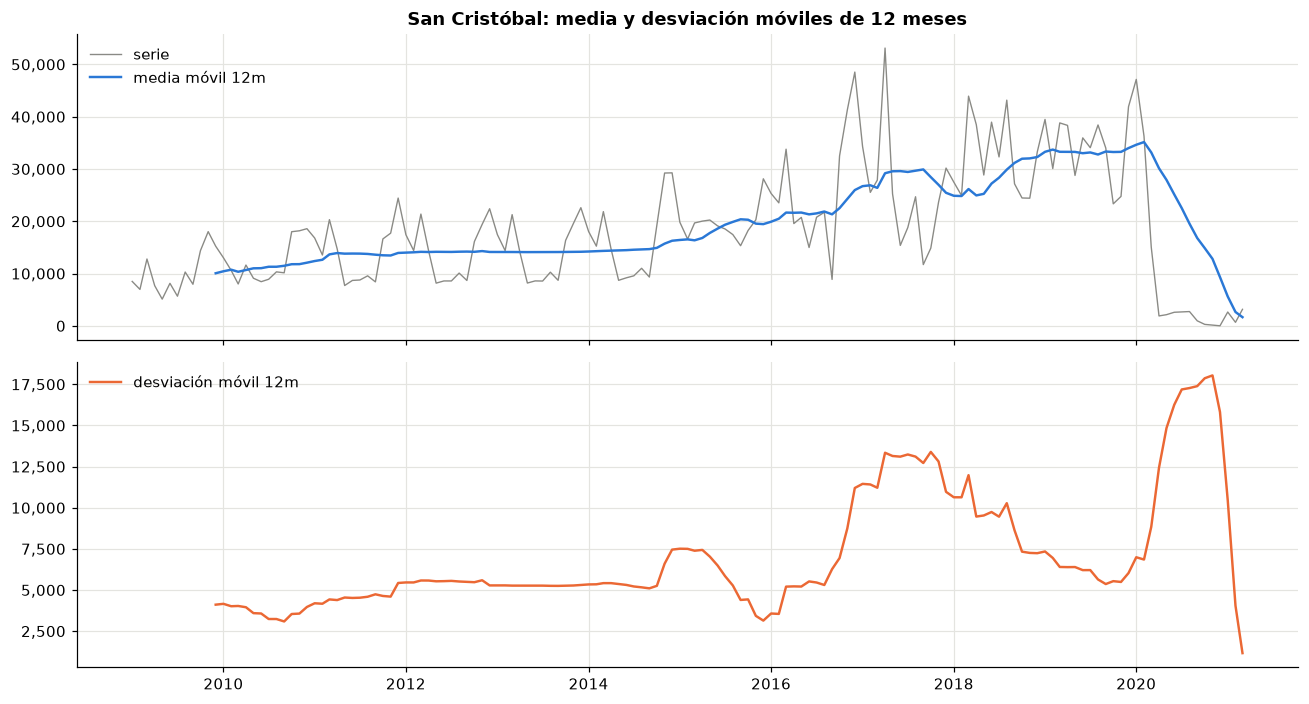

In [30]:
graficar_moviles(scristobal, "San Cristóbal: media y desviación móviles de 12 meses", "serie-scristobal-moviles")

Media móvil que se duplica y se desploma: **no estacionaria en media**. La desviación móvil sube
de 4,800 a 8,000 entre mitades prepandemia, un 67%, acompañando a la media: **no estacionaria en
varianza**, con un caso más claro que el de Valle Nuevo.

### 6.3 Descomposición

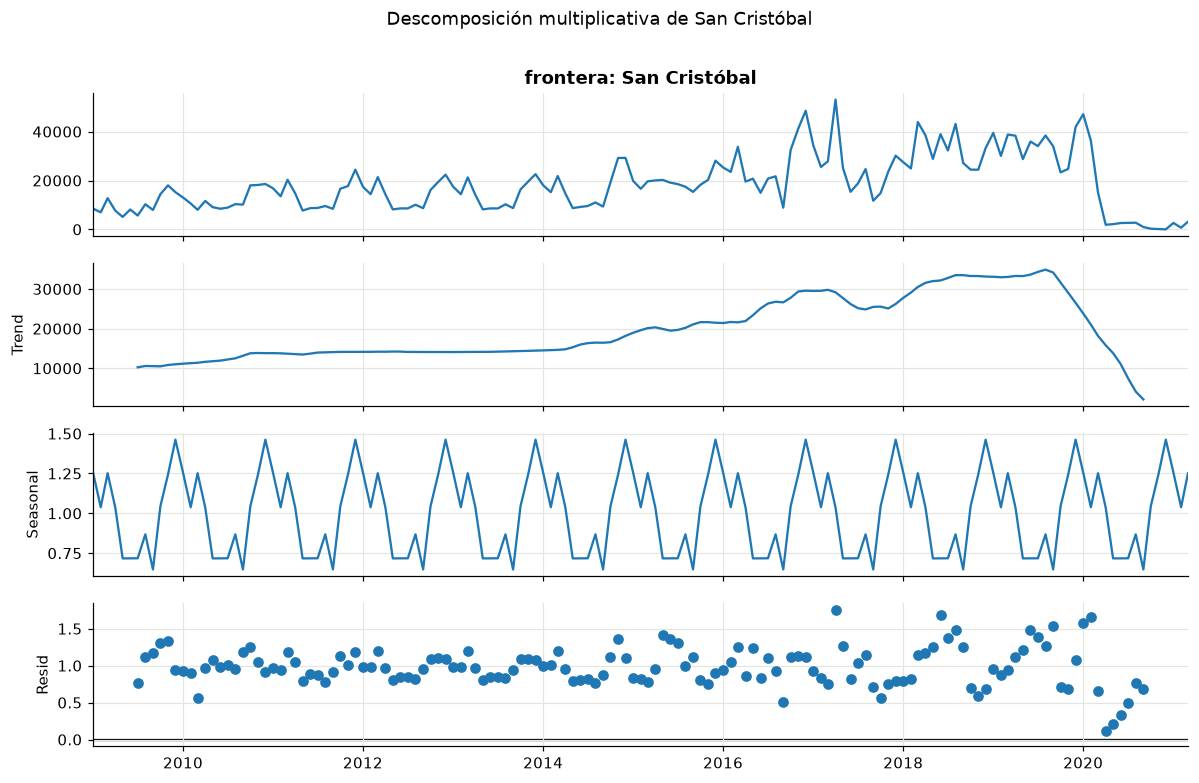

,residuo aditivo (rel. al nivel medio),residuo multiplicativo (rel. a 1)
desv. estándar relativa (prepandemia),0.232,0.2082


In [31]:
desc_scristobal, comparacion_scristobal = descomponer(
    scristobal, "Descomposición multiplicativa de San Cristóbal", "serie-scristobal-descomposicion")
comparacion_scristobal

El calendario estacional de San Cristóbal es el más marcado y el más distinto: diciembre 143,
marzo 128 y noviembre 127 como picos, y un valle profundo y largo de mayo a septiembre con el
piso en septiembre (62). La banda total va de 62 a 143, la más ancha de las cinco series. El
residuo es también el más ruidoso (20.8% multiplicativo, 23.2% aditivo), y aquí la
multiplicativa vuelve a ganar. Conclusión: **no estacionaria en media ni en varianza**, con la
estacionalidad más ancha y el ruido más alto del grupo.

### 6.4 Transformación y estacionariedad en media

El logaritmo se justifica sin ambigüedad: la dispersión crece con el nivel, la descomposición
favorece la multiplicativa y el colapso de 2020 (mínimo 14, sin ceros) necesita compresión de
escala.

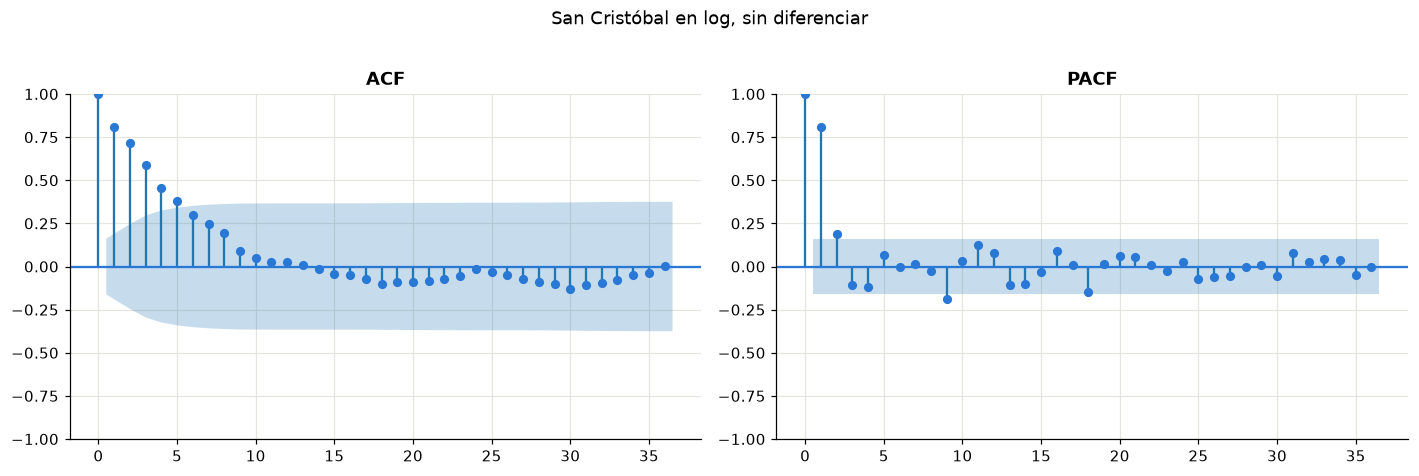

,ADF estadístico,ADF p-valor,ADF veredicto,KPSS estadístico,KPSS p-valor,KPSS veredicto
nivel (log),-2.08,0.2527,NO estacionaria,0.175,0.1,estacionaria
1a diferencia,-0.388,0.9121,NO estacionaria,0.087,0.1,estacionaria
1a diferencia + estacional (12),-4.467,0.0002,estacionaria,0.032,0.1,estacionaria


In [32]:
scristobal_log = np.log(scristobal)
correlogramas(scristobal_log, "San Cristóbal en log, sin diferenciar", "serie-scristobal-acf-nivel")
tabla_estacionariedad(scristobal_log, {
    "nivel (log)": scristobal_log,
    "1a diferencia": scristobal_log.diff(),
    "1a diferencia + estacional (12)": scristobal_log.diff().diff(12),
})

El nivel no es estacionario (ACF lenta: 0.81 en el rezago 1; ADF p = 0.25), como en todas las
series. La diferencia está en el paso siguiente: **la primera diferencia sola no alcanza**. El
ADF sobre la serie con d = 1 no rechaza la raíz unitaria (p = 0.91), el único caso entre las
cinco series analizadas. La estacionalidad ancha que mostró la descomposición deja tanta
estructura anual en la serie diferenciada que la prueba no la distingue de una caminata
aleatoria. Con la **diferencia estacional adicional** el ADF rechaza (p = 0.0002).

Para San Cristóbal la receta es **d = 1 y D = 1 obligatorias**, sin la ambigüedad de las otras
fronteras: aquí la evidencia estadística exige ambas diferenciaciones.

### 6.5 Correlogramas de la serie estacionaria

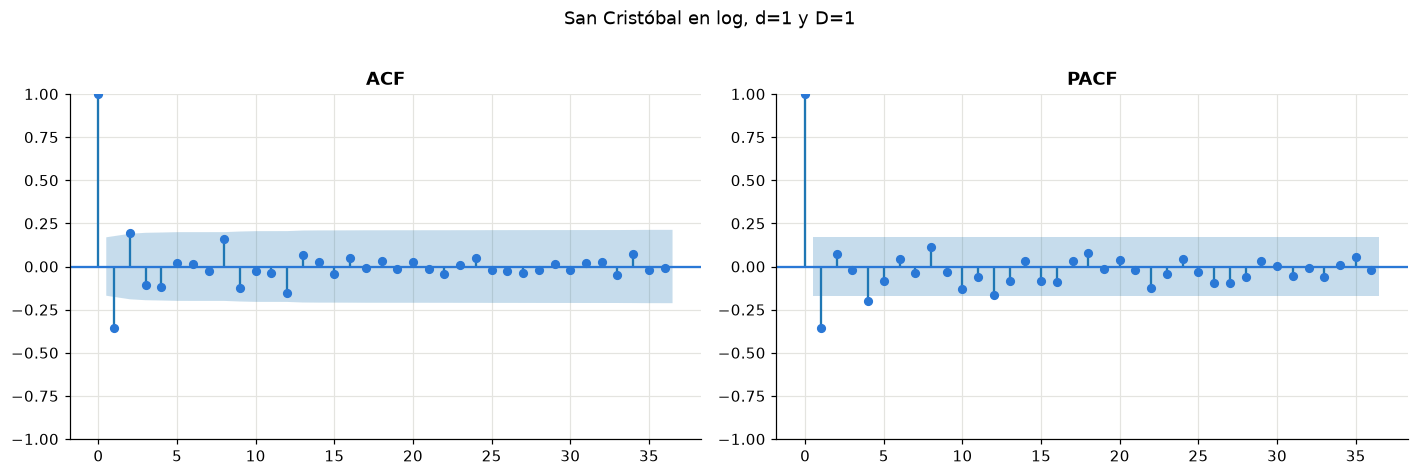

In [33]:
scristobal_estacionaria = scristobal_log.diff().diff(12)
correlogramas(scristobal_estacionaria, "San Cristóbal en log, d=1 y D=1", "serie-scristobal-acf-estacionaria")

El rezago 1 es el más negativo de todas las series (-0.36 en ACF y PACF) y la ACF corta después
del 2 (0.19 marginal), mientras la PACF decae: estructura de **media móvil regular, q = 1 con
q = 2 como alternativa**. En la parte estacional ningún rezago cruza la banda, pero D = 1 ya
absorbió la estacionalidad y el ruido de esta serie es alto; mantenemos **Q en {0, 1}** para la
búsqueda. Candidatos: **SARIMA(0,1,1)(0,1,1)₁₂ y SARIMA(0,1,2)(0,1,0)₁₂** sobre el log.

## 7. Serie regional: América Del Norte

Las dos regiones que faltan, América Del Norte y Europa, son las regiones segunda y tercera por
acumulado y cierran las tres series de la categoría. Traen una diferencia respecto de las cinco
anteriores: durante el cierre de fronteras de 2020 registran cinco meses exactamente en cero
(abril a agosto). Eso obliga a dos ajustes. La transformación no puede ser `log` porque el
logaritmo de cero no existe, así que usamos **log(1 + x)**, que coincide con el logaritmo para
los valores grandes de estas series y vale cero cuando la serie vale cero. Y la descomposición
multiplicativa tampoco admite ceros, así que descomponemos de forma **aditiva sobre el log**,
que es la misma estructura multiplicativa vista en escala logarítmica y sí está definida en el
piso pandémico. Definimos ese helper una vez y lo usan las dos secciones.

In [34]:
def descomponer_ceros(serie, titulo, nombre_figura):
    """Descomposición para las series con meses en cero (Norte y Europa).

    Multiplicative no admite ceros, así que graficamos la descomposición aditiva del
    log(1+x): la misma estructura multiplicativa vista en logaritmo. La comparación
    aditivo vs multiplicativo se hace sobre el tramo prepandemia (sin ceros), igual
    que en las demás series, para caracterizar la estacionalidad en niveles.
    """
    desc = seasonal_decompose(np.log1p(serie), model="additive", period=12)
    fig = desc.plot()
    fig.set_size_inches(11, 7)
    fig.suptitle(titulo + " (aditiva sobre log(1+x))", y=1.01)
    guardar(nombre_figura)
    plt.show()

    pre = serie[:"2019-12"]  # el tramo prepandemia no tiene ceros
    resid_add = seasonal_decompose(pre, model="additive", period=12).resid.dropna()
    resid_mul = seasonal_decompose(pre, model="multiplicative", period=12).resid.dropna()
    comparacion = pd.DataFrame({
        "residuo aditivo (rel. al nivel medio)": [resid_add.std() / pre.mean()],
        "residuo multiplicativo (rel. a 1)": [resid_mul.std()],
    }, index=["desv. estándar relativa (prepandemia)"]).round(4)
    return desc, comparacion

### 7.1 Inicio, fin, frecuencia y primer vistazo

Segunda región por acumulado, 9.16 millones de visitantes en el período completo, el 20% del
total. Misma cobertura que las demás, **enero 2009 a marzo 2021** en entrenamiento, **frecuencia
mensual**, 147 observaciones. Es, en esencia, el mercado estadounidense y canadiense.

Inicio     : 2009-01
Fin        : 2021-03
Frecuencia : mensual (MS), 147 observaciones
Media      : 38,326 visitantes/mes | CV = 0.36
Máximo     : 66,272 en 2019-07
Mínimo     : 0 en 2020-04 (mes de cierre)
Meses en cero: 5 (2020-04, 2020-05, 2020-06, 2020-07, 2020-08)


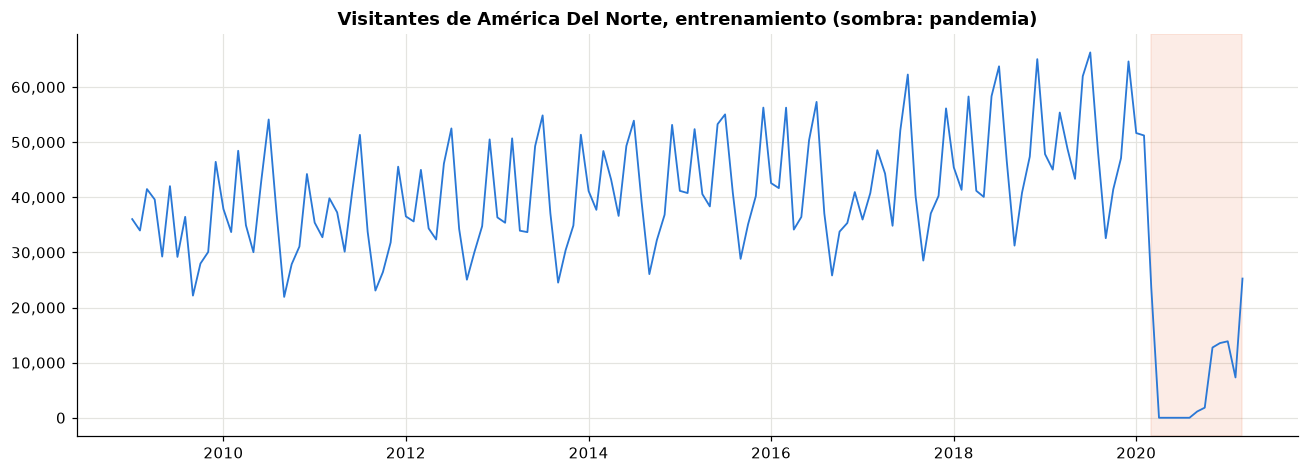

In [35]:
norte = train["region: América Del Norte"]
print(f"Inicio     : {norte.index.min():%Y-%m}")
print(f"Fin        : {norte.index.max():%Y-%m}")
print(f"Frecuencia : mensual ({norte.index.freqstr}), {len(norte)} observaciones")
print(f"Media      : {norte.mean():,.0f} visitantes/mes | CV = {norte.std() / norte.mean():.2f}")
print(f"Máximo     : {norte.max():,.0f} en {norte.idxmax():%Y-%m}")
print(f"Mínimo     : {norte.min():,.0f} en {norte.idxmin():%Y-%m} (mes de cierre)")
print(f"Meses en cero: {(norte == 0).sum()} ({', '.join(f'{d:%Y-%m}' for d in norte[norte == 0].index)})")
graficar_serie(norte, "Visitantes de América Del Norte, entrenamiento (sombra: pandemia)",
               "serie-norte")

La anatomía general se repite, crecimiento hasta 2019 y colapso en 2020, pero el calendario es
distinto al de América Del Centro. Su punto más alto no es diciembre sino **julio** (66,272 en
julio 2019), el verano del hemisferio norte, cuando el turista estadounidense viaja. Es el mismo
calendario que veíamos en La Aurora, coherente con que este mercado entra sobre todo por vía
aérea. Con CV 0.36 es algo menos volátil que América Del Centro (0.45). Y su recuperación al
cierre del entrenamiento es la más rápida de las tres regiones, en marzo 2021 lleva 25,250
visitantes contra un promedio 2019 de 50,213, el **50%**, mientras Centro apenas recuperaba el
20%. La reapertura del mercado aéreo norteamericano llegó antes que la de las fronteras
terrestres, y eso se nota aquí.

### 7.2 Media y desviación móviles

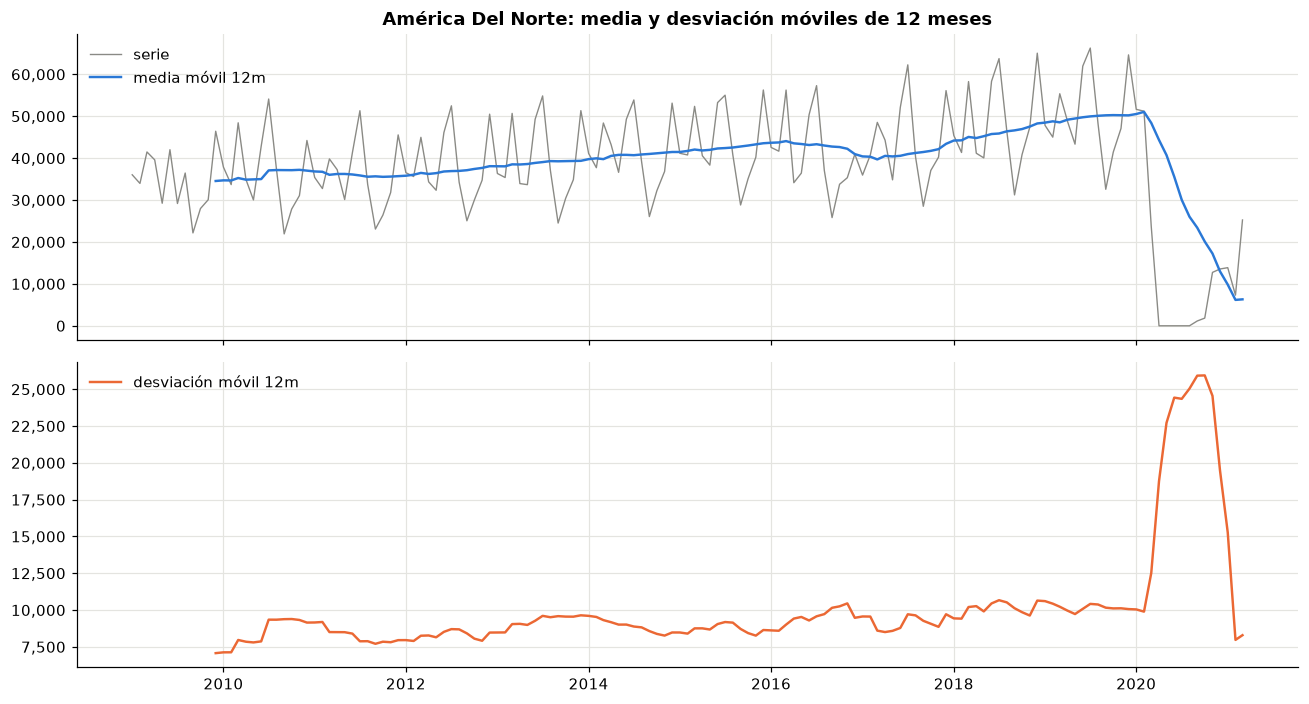

In [36]:
graficar_moviles(norte, "América Del Norte: media y desviación móviles de 12 meses", "serie-norte-moviles")

Media móvil creciente once años y desplomada en 2020, **no estacionaria en media**. La
desviación móvil sube de unos 8,500 a 9,500 entre las dos mitades del tramo prepandemia, un
crecimiento más leve que el de Centro pero presente, así que **no estacionaria en varianza**,
con evidencia algo más débil que en las series grandes.

### 7.3 Descomposición

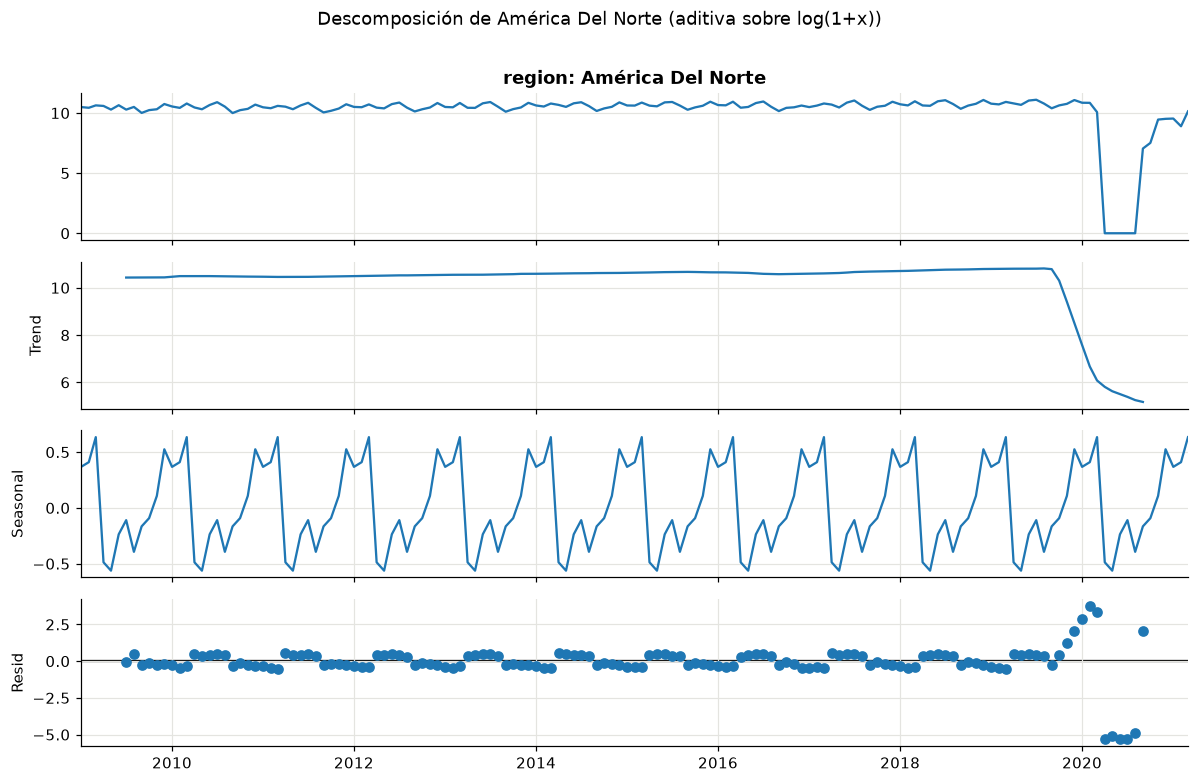

,residuo aditivo (rel. al nivel medio),residuo multiplicativo (rel. a 1)
desv. estándar relativa (prepandemia),0.0682,0.06


In [37]:
desc_norte, comparacion_norte = descomponer_ceros(
    norte, "Descomposición de América Del Norte", "serie-norte-descomposicion")
comparacion_norte

La estacionalidad confirma el calendario de verano, julio corre un 33% arriba del mes promedio y
septiembre un 36% abajo, la banda estacional más marcada por el verano boreal en vez de la
Navidad. El residuo multiplicativo prepandemia (6.0%) le gana al aditivo (6.8%), así que la
estructura sigue siendo multiplicativa pese a los ceros de 2020. Conclusión igual que las
demás, **no estacionaria ni en media ni en varianza**, con estacionalidad anual de período 12.

### 7.4 Transformación y estacionariedad en media

La serie **necesita log(1 + x)** en vez de `log`, porque su mínimo es cero en los cinco meses de
cierre. Sobre esa transformación corremos el diagnóstico de estacionariedad en media.

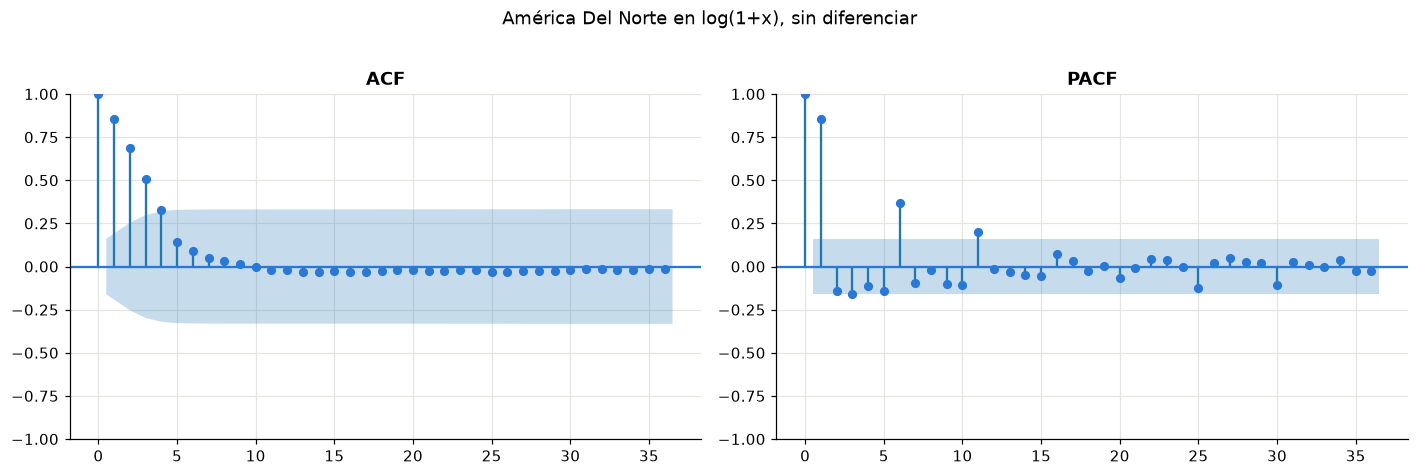

,ADF estadístico,ADF p-valor,ADF veredicto,KPSS estadístico,KPSS p-valor,KPSS veredicto
nivel (log),-2.346,0.1576,NO estacionaria,0.355,0.0966,estacionaria
1a diferencia,-2.87,0.0489,estacionaria,0.02,0.1,estacionaria
1a diferencia + estacional (12),-4.977,0.0,estacionaria,0.024,0.1,estacionaria


In [38]:
norte_log = np.log1p(norte)
correlogramas(norte_log, "América Del Norte en log(1+x), sin diferenciar", "serie-norte-acf-nivel")
tabla_estacionariedad(norte_log, {
    "nivel (log)": norte_log,
    "1a diferencia": norte_log.diff(),
    "1a diferencia + estacional (12)": norte_log.diff().diff(12),
})

La ACF del nivel decae lento (0.85 en el rezago 1) y el ADF no rechaza la raíz unitaria
(p = 0.16), **no estacionaria en media**. Con **una diferencia regular** el ADF ya rechaza,
aunque al borde (p = 0.049). Aquí aparece un matiz propio, en la ACF de la primera diferencia el
rezago estacional 12 queda dentro de la banda (0.03), muy por debajo del que mostraban el total
o Centro. El salto del colapso pandémico contamina esa estimación, así que la diferencia
estacional queda como **opcional**, igual que en La Aurora y Valle Nuevo, y con ella el rechazo
es contundente (p < 0.0001). El candidato es **d = 1**, con **D = 1 a comparar contra D = 0** en
el modelado.

### 7.5 Correlogramas de la serie estacionaria

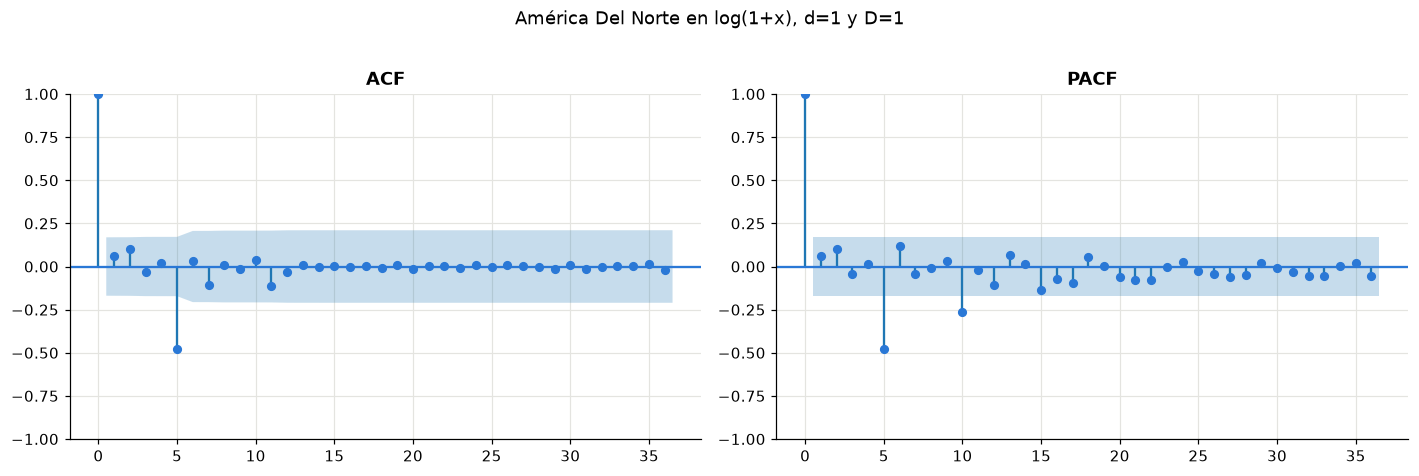

In [39]:
norte_estacionaria = norte_log.diff().diff(12)
correlogramas(norte_estacionaria, "América Del Norte en log(1+x), d=1 y D=1", "serie-norte-acf-estacionaria")

## 8. Serie regional: Europa

### 8.1 Inicio, fin, frecuencia y primer vistazo

Tercera región por acumulado, 2.15 millones de visitantes, el 4.6% del total. Misma cobertura,
**enero 2009 a marzo 2021**, **frecuencia mensual**, 147 observaciones. Es la más pequeña de las
tres series regionales y, como Norte, trae los cinco meses en cero de 2020.

Inicio     : 2009-01
Fin        : 2021-03
Frecuencia : mensual (MS), 147 observaciones
Media      : 9,593 visitantes/mes | CV = 0.39
Máximo     : 16,224 en 2020-02
Mínimo     : 0 en 2020-04 (mes de cierre)
Meses en cero: 5 (2020-04, 2020-05, 2020-06, 2020-07, 2020-08)


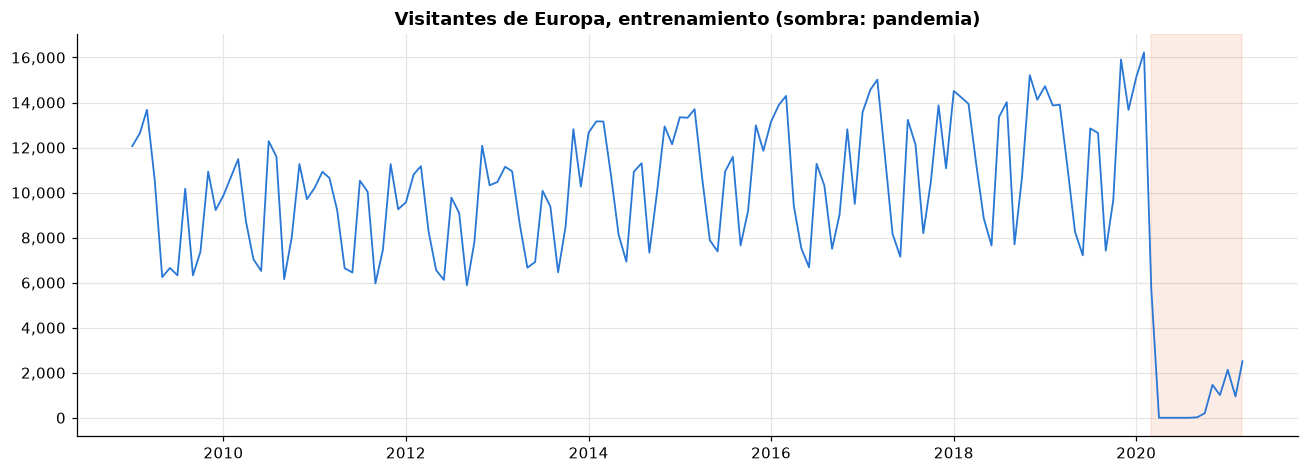

In [40]:
europa = train["region: Europa"]
print(f"Inicio     : {europa.index.min():%Y-%m}")
print(f"Fin        : {europa.index.max():%Y-%m}")
print(f"Frecuencia : mensual ({europa.index.freqstr}), {len(europa)} observaciones")
print(f"Media      : {europa.mean():,.0f} visitantes/mes | CV = {europa.std() / europa.mean():.2f}")
print(f"Máximo     : {europa.max():,.0f} en {europa.idxmax():%Y-%m}")
print(f"Mínimo     : {europa.min():,.0f} en {europa.idxmin():%Y-%m} (mes de cierre)")
print(f"Meses en cero: {(europa == 0).sum()} ({', '.join(f'{d:%Y-%m}' for d in europa[europa == 0].index)})")
graficar_serie(europa, "Visitantes de Europa, entrenamiento (sombra: pandemia)", "serie-europa")

Europa trae un tercer calendario, distinto de los dos anteriores. Sus picos son **noviembre y
febrero** y su valle es junio, el patrón del viajero europeo que escapa del invierno boreal
hacia el trópico. Su máximo cae en febrero de 2020 (16,224), el último mes normal antes del
cierre, lo que deja el desplome de marzo especialmente abrupto. Con CV 0.39 su volatilidad
relativa es parecida a la de Norte. Su recuperación al corte es lenta, como la de Centro, en
marzo 2021 lleva 2,511 visitantes contra un promedio 2019 de 11,770, el **21%**, coherente con
un mercado de larga distancia que tardó más en volver.

### 8.2 Media y desviación móviles

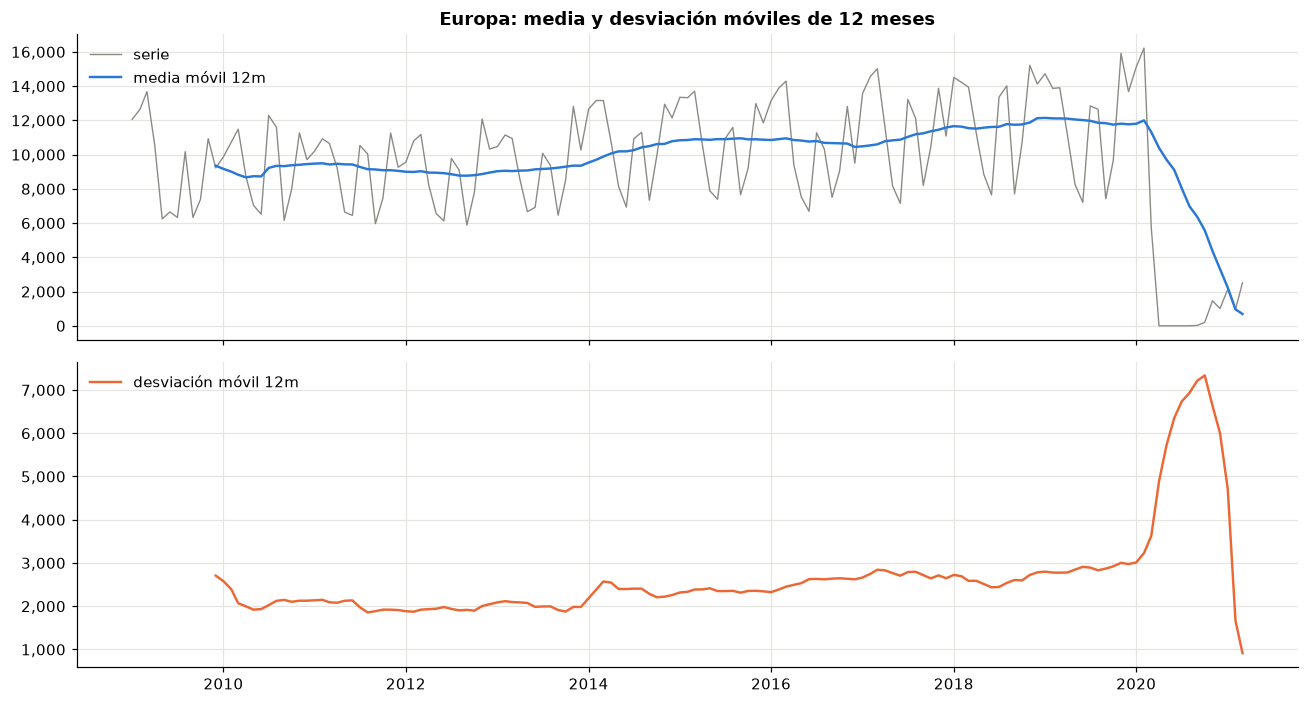

In [41]:
graficar_moviles(europa, "Europa: media y desviación móviles de 12 meses", "serie-europa-moviles")

Mismo diagnóstico visual. Media móvil creciente y desplomada, **no estacionaria en media**.
Desviación móvil que sube de unos 2,000 a 2,600 entre las dos mitades del tramo prepandemia,
**no estacionaria en varianza**.

### 8.3 Descomposición

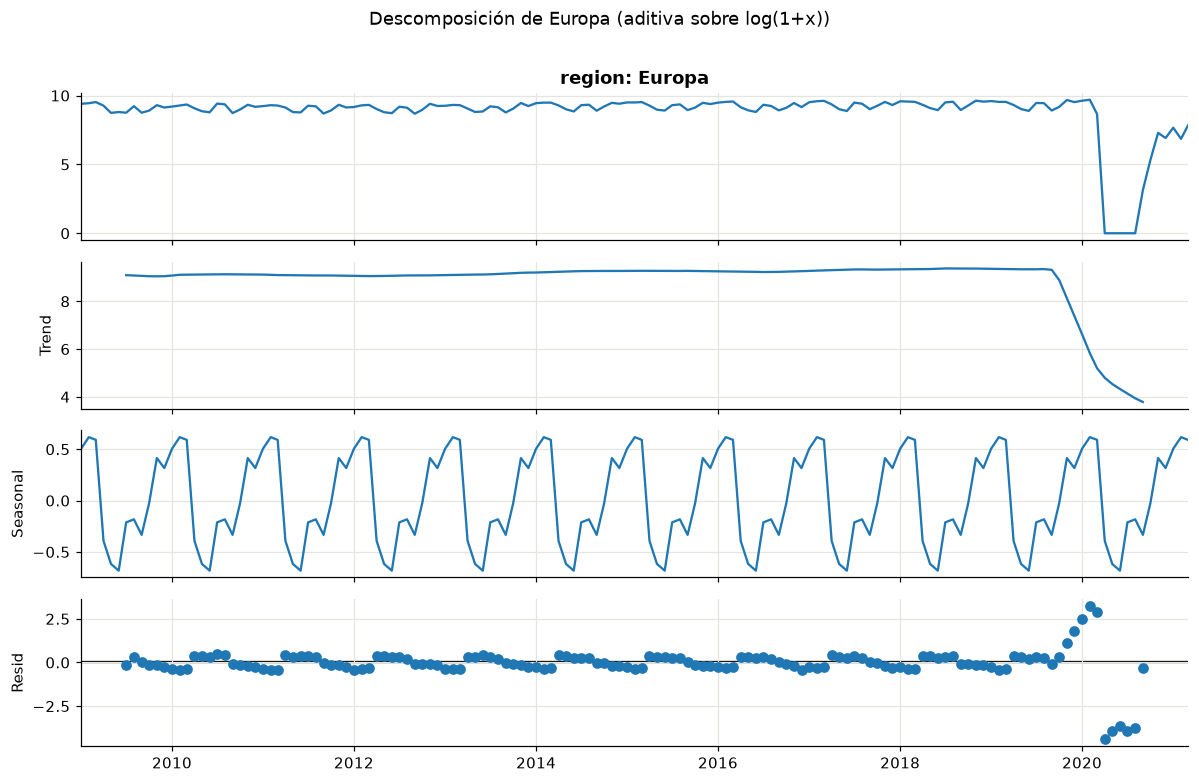

,residuo aditivo (rel. al nivel medio),residuo multiplicativo (rel. a 1)
desv. estándar relativa (prepandemia),0.0709,0.0638


In [42]:
desc_europa, comparacion_europa = descomponer_ceros(
    europa, "Descomposición de Europa", "serie-europa-descomposicion")
comparacion_europa

La descomposición confirma el calendario invernal, noviembre corre un 25% arriba del mes
promedio y junio un 33% abajo, con diciembre y febrero también altos. El residuo multiplicativo
prepandemia (6.4%) vuelve a ganarle al aditivo (7.1%). Conclusión igual, **no estacionaria ni en
media ni en varianza**, con estacionalidad de período 12.

### 8.4 Transformación y estacionariedad en media

Como Norte, **necesita log(1 + x)** por sus cinco meses en cero.

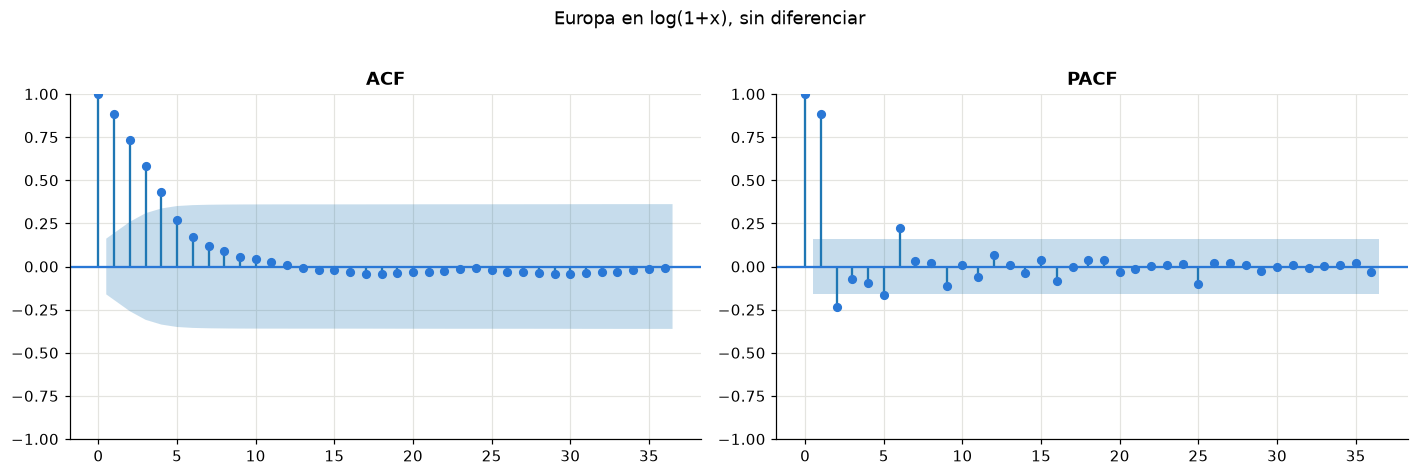

,ADF estadístico,ADF p-valor,ADF veredicto,KPSS estadístico,KPSS p-valor,KPSS veredicto
nivel (log),-2.004,0.2848,NO estacionaria,0.401,0.0767,estacionaria
1a diferencia,-2.506,0.114,NO estacionaria,0.023,0.1,estacionaria
1a diferencia + estacional (12),-4.975,0.0,estacionaria,0.028,0.1,estacionaria


In [43]:
europa_log = np.log1p(europa)
correlogramas(europa_log, "Europa en log(1+x), sin diferenciar", "serie-europa-acf-nivel")
tabla_estacionariedad(europa_log, {
    "nivel (log)": europa_log,
    "1a diferencia": europa_log.diff(),
    "1a diferencia + estacional (12)": europa_log.diff().diff(12),
})

La ACF del nivel decae lento (0.89 en el rezago 1) y el ADF no rechaza (p = 0.28), **no
estacionaria en media**. Aquí aparece el rasgo que distingue a Europa, con **una sola diferencia
regular no basta**, el ADF sigue sin rechazar (p = 0.11). Solo al agregar la **diferencia
estacional** la serie se vuelve estacionaria (p < 0.0001). Es el mismo caso de San Cristóbal, la
estacionalidad es tan dominante que hay que removerla para estabilizar la media. El candidato
es **d = 1 y D = 1**, con la diferencia estacional **obligatoria**, no opcional.

### 8.5 Correlogramas de la serie estacionaria

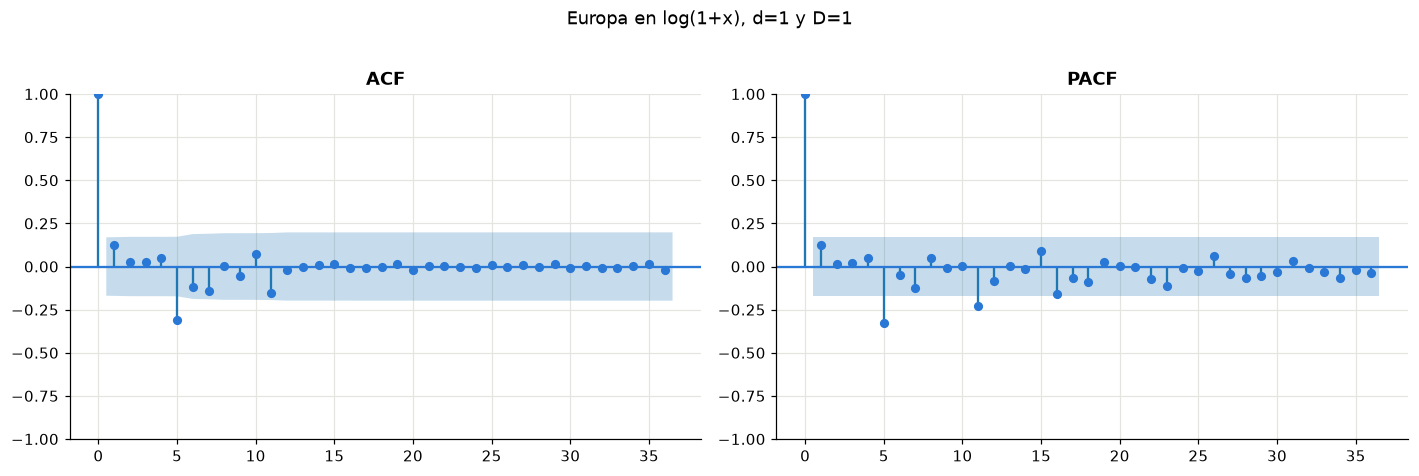

In [44]:
europa_estacionaria = europa_log.diff().diff(12)
correlogramas(europa_estacionaria, "Europa en log(1+x), d=1 y D=1", "serie-europa-acf-estacionaria")

## 9. Conclusiones del análisis preliminar

Las siete series analizadas (el total, las tres regiones y las tres fronteras) comparten el
diagnóstico de fondo y difieren en matices que van a importar al modelar.

**Lo común.** Ninguna es estacionaria en media: tendencia creciente de once años más el colapso
de 2020, y el ADF no rechaza en el nivel en ninguna (p entre 0.12 y 0.28). Ninguna es
estacionaria en varianza, aunque la fuerza de la evidencia varía: clara en el total, América Del
Centro y San Cristóbal, más débil en Valle Nuevo, América Del Norte y Europa. Las siete se
modelan en **logaritmo**, con **d = 1** y componente estacional de **período 12**. En América
Del Norte y Europa el logaritmo es **log(1 + x)** por sus cinco meses en cero del cierre de 2020.
El candidato de partida común es un SARIMA(0,1,1)(0,1,1)₁₂ sobre el log.

**La diferencia estacional separa a las series en tres grupos.** En el total y América Del
Centro es necesaria: los rezagos 12 y 24 de la serie con d = 1 quedan significativos. En La
Aurora, Valle Nuevo y América Del Norte es opcional: esos rezagos caen dentro de la banda
—en Norte el colapso pandémico contamina la estimación estacional— y compararemos D = 1 contra
D = 0. En San Cristóbal y Europa es obligatoria y con ella no basta d = 1: son las dos series
donde el ADF no rechaza tras la primera diferencia (San Cristóbal p = 0.91, Europa p = 0.11) y
solo rechaza con las dos diferencias.

**Los matices por serie.** Cada serie trae su propio calendario. América Del Centro tiene el
pico de diciembre (+39%) por la visita familiar de fin de año; América Del Norte lo tiene en
julio (+33%) por el verano boreal, el mismo calendario aéreo de La Aurora; Europa lo tiene en
noviembre y febrero, el viajero que huye del invierno del norte. En volatilidad, La Aurora es la
más estable (CV 0.33) y San Cristóbal la más volátil (0.61), con las regiones en medio (0.36 a
0.45). En recuperación al corte del entrenamiento, el mercado aéreo norteamericano fue el más
rápido (50% de su nivel 2019 en marzo 2021), seguido de La Aurora (48%), mientras las fronteras
terrestres y Europa apenas llegaban al 20%: la reapertura aérea llegó primero y eso marca qué
tan difícil es el arranque de la prueba para cada serie.

**La advertencia para la fase de modelado.** El corte 70/30 deja el colapso pandémico en los
últimos doce meses del entrenamiento y toda la recuperación en la prueba. Los modelos van a
aprender un final de serie anómalo y se evaluarán sobre un régimen que no vieron, y el problema
es peor en las fronteras terrestres y en Europa, cuyo punto de partida en la prueba está más
lejos de su nivel normal. Al comparar algoritmos hay que leer las métricas de error con ese
sesgo en mente.

Con las siete series diagnosticadas, queda pendiente la fase de modelado y comparación del punto
4f al 4k: la rejilla de modelos SARIMA por serie, los algoritmos alternativos (Prophet,
Holt-Winters, suavizamiento exponencial y seasonal naive), la predicción sobre la prueba y la
selección por métricas de error, AIC y BIC.